# Cellpose analysis of PanNuke fold 1: neoplastic vs normal nuclei

This notebook evaluates **Cellpose nuclear segmentation** on **PanNuke fold 1** and compares performance between:

- neoplastic nuclei,
- normal / non-neoplastic nuclei,
- normal subtypes: inflammatory, connective, dead, and epithelial.




In [11]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from skimage.measure import label, regionprops
from skimage.segmentation import find_boundaries
from skimage.metrics import adapted_rand_error, variation_of_information

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

from cellpose import models



In [12]:
DATA_DIR = Path("Fold_1")

IMAGES_FILE = DATA_DIR / "images" / "fold1" / "images.npy"
MASKS_FILE  = DATA_DIR / "masks" / "fold1" / "masks.npy"
TYPES_FILE  = DATA_DIR / "images" / "fold1" / "types.npy"

MAX_IMAGES = 100
RANDOM_SEED = 42
USE_GPU = False
CELLPOSE_MODEL = "nuclei"
DIAMETER = None  

MATCH_IOU_THRESHOLDS = [0.10, 0.25, 0.50]
PRIMARY_MATCH_IOU = 0.10
MIN_OVERLAP_FRACTION = 0.20
OUT_DIR = DATA_DIR / "cellpose_fold1_analysis"
TABLE_DIR = OUT_DIR / "tables"
FIGURE_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(exist_ok=True, parents=True)
TABLE_DIR.mkdir(exist_ok=True, parents=True)
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

# Figure saving.
FIGURE_DPI = 300
SAVE_PDF_FIGURES = True
DISPLAY_FIGURES = True


def safe_filename(name):
    name = re.sub(r"[^\w\-.]+", "_", str(name))
    name = re.sub(r"_+", "_", name)
    return name.strip("_").lower()


def save_fig(name, fig=None, close=True):
    if fig is None:
        fig = plt.gcf()

    filename = safe_filename(name)
    png_path = FIGURE_DIR / f"{filename}.png"
    pdf_path = FIGURE_DIR / f"{filename}.pdf"

    fig.tight_layout()
    fig.savefig(png_path, dpi=FIGURE_DPI, bbox_inches="tight")

    if SAVE_PDF_FIGURES:
        fig.savefig(pdf_path, bbox_inches="tight")

    if DISPLAY_FIGURES:
        plt.show()

    if close:
        plt.close(fig)

    print(f"Saved figure: {png_path}")



In [13]:
# =========================
# Load PanNuke fold1
# =========================

images = np.load(IMAGES_FILE)
masks = np.load(MASKS_FILE)
types = np.load(TYPES_FILE, allow_pickle=True)

print("images shape:", images.shape)
print("masks shape: ", masks.shape)
print("types shape: ", types.shape)
print("example tissue types:", np.unique(types)[:30])


images shape: (2656, 256, 256, 3)
masks shape:  (2656, 256, 256, 6)
types shape:  (2656,)
example tissue types: ['Adrenal_gland' 'Bile-duct' 'Bladder' 'Breast' 'Cervix' 'Colon'
 'Esophagus' 'HeadNeck' 'Kidney' 'Liver' 'Lung' 'Ovarian' 'Pancreatic'
 'Prostate' 'Skin' 'Stomach' 'Testis' 'Thyroid' 'Uterus']


In [14]:
def inspect_pannuke_channels(mask):
    print("single mask shape:", mask.shape)
    for ch in range(mask.shape[-1]):
        channel = mask[..., ch]
        ids = np.unique(channel)
        ids = ids[ids > 0]
        print(
            f"channel {ch}: "
            f"nonzero pixels = {np.sum(channel > 0)}, "
            f"objects = {len(ids)}"
        )

inspect_pannuke_channels(masks[0])


single mask shape: (256, 256, 6)
channel 0: nonzero pixels = 4374, objects = 4
channel 1: nonzero pixels = 785, objects = 2
channel 2: nonzero pixels = 1177, objects = 2
channel 3: nonzero pixels = 0, objects = 0
channel 4: nonzero pixels = 0, objects = 0
channel 5: nonzero pixels = 59200, objects = 1


## Helper functions


In [15]:
# PanNuke definitions

PANNUKE_CLASS_NAMES = {
    0: "neoplastic",
    1: "inflammatory",
    2: "connective",
    3: "dead",
    4: "epithelial",
    5: "background",
}

CELL_CHANNELS = [0, 1, 2, 3, 4]
CANCER_CHANNELS = [0]
NORMAL_CHANNELS = [1, 2, 3, 4]


def normalize_to_uint8(img):
    img = np.asarray(img)

    if img.dtype == np.uint8:
        return img

    img = img.astype(np.float32)

    if img.max() <= 1.0:
        img = img * 255.0

    return np.clip(img, 0, 255).astype(np.uint8)


def get_cell_channels(mask):

    if mask.shape[-1] >= 6:
        return mask[..., :5]
    return mask


def pannuke_binary_mask(mask):
    return np.any(get_cell_channels(mask) > 0, axis=-1)


def pannuke_cancer_mask(mask):
    return mask[..., 0] > 0


def pannuke_normal_mask(mask):
    available = [ch for ch in NORMAL_CHANNELS if ch < mask.shape[-1]]
    if len(available) == 0:
        return np.zeros(mask.shape[:2], dtype=bool)
    return np.any(mask[..., available] > 0, axis=-1)


def pannuke_class_mask(mask, channel):
    if channel >= mask.shape[-1]:
        return np.zeros(mask.shape[:2], dtype=bool)
    return mask[..., channel] > 0


def count_pannuke_instances(mask, channels=None):
    if channels is None:
        channels = CELL_CHANNELS

    count = 0
    for ch in channels:
        if ch >= mask.shape[-1]:
            continue
        ids = np.unique(mask[..., ch])
        ids = ids[ids > 0]
        count += len(ids)

    return int(count)


def pannuke_instance_mask(mask):
    out = np.zeros(mask.shape[:2], dtype=np.int32)
    current_id = 1

    for ch in CELL_CHANNELS:
        if ch >= mask.shape[-1]:
            continue

        channel = mask[..., ch]
        ids = np.unique(channel)
        ids = ids[ids > 0]

        for obj_id in ids:
            out[channel == obj_id] = current_id
            current_id += 1

    return out


def count_instances(binary_mask):
    return int(label(binary_mask).max())


def segmentation_metrics(gt_binary, pred_binary):
    gt = gt_binary.astype(bool)
    pred = pred_binary.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    tn = np.logical_and(~gt, ~pred).sum()

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    return {
        "tp_pixels": int(tp),
        "fp_pixels": int(fp),
        "fn_pixels": int(fn),
        "tn_pixels": int(tn),
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
    }


def safe_instance_metrics(gt_instance, pred_instance):
    try:
        are, precision, recall = adapted_rand_error(gt_instance, pred_instance)
    except Exception:
        are, precision, recall = np.nan, np.nan, np.nan

    try:
        vi_split, vi_merge = variation_of_information(gt_instance, pred_instance)
    except Exception:
        vi_split, vi_merge = np.nan, np.nan

    return {
        "adapted_rand_error": float(are),
        "adapted_rand_precision": float(precision),
        "adapted_rand_recall": float(recall),
        "vi_split": float(vi_split),
        "vi_merge": float(vi_merge),
    }


In [16]:
# Object-level helper functions
GT_OBJECT_COLUMNS = [
    "image_index",
    "tissue_type",
    "gt_channel",
    "gt_class",
    "gt_broad_class",
    "gt_original_id",
    "gt_uid",
    "gt_area",
    "gt_bbox_min_row",
    "gt_bbox_min_col",
    "gt_bbox_max_row",
    "gt_bbox_max_col",
    "gt_centroid_row",
    "gt_centroid_col",
    "gt_eccentricity",
    "gt_solidity",
    "gt_major_axis_length",
    "gt_minor_axis_length",
]

PRED_OBJECT_COLUMNS = [
    "image_index",
    "tissue_type",
    "pred_id",
    "pred_uid",
    "pred_assigned_class",
    "pred_area",
    "pred_bbox_min_row",
    "pred_bbox_min_col",
    "pred_bbox_max_row",
    "pred_bbox_max_col",
    "pred_centroid_row",
    "pred_centroid_col",
    "pred_eccentricity",
    "pred_solidity",
    "pred_major_axis_length",
    "pred_minor_axis_length",
    "pred_cancer_overlap_px",
    "pred_normal_overlap_px",
    "pred_any_gt_overlap_px",
    "pred_cancer_overlap_fraction",
    "pred_normal_overlap_fraction",
    "pred_any_gt_overlap_fraction",
]


def build_gt_object_table(mask, image_index, tissue_type):
    rows = []

    for ch in CELL_CHANNELS:
        if ch >= mask.shape[-1]:
            continue

        channel_img = mask[..., ch].astype(np.int32)
        ids = np.unique(channel_img)
        ids = ids[ids > 0]

        class_name = PANNUKE_CLASS_NAMES.get(ch, f"channel_{ch}")
        broad_class = "neoplastic" if ch == 0 else "normal"

        for original_id in ids:
            obj = channel_img == original_id
            props = regionprops(obj.astype(np.uint8))

            if len(props) == 0:
                continue

            p = props[0]

            rows.append({
                "image_index": int(image_index),
                "tissue_type": str(tissue_type),
                "gt_channel": int(ch),
                "gt_class": class_name,
                "gt_broad_class": broad_class,
                "gt_original_id": int(original_id),
                "gt_uid": f"{int(image_index)}__ch{int(ch)}__id{int(original_id)}",
                "gt_area": float(p.area),
                "gt_bbox_min_row": int(p.bbox[0]),
                "gt_bbox_min_col": int(p.bbox[1]),
                "gt_bbox_max_row": int(p.bbox[2]),
                "gt_bbox_max_col": int(p.bbox[3]),
                "gt_centroid_row": float(p.centroid[0]),
                "gt_centroid_col": float(p.centroid[1]),
                "gt_eccentricity": float(p.eccentricity),
                "gt_solidity": float(p.solidity),
                "gt_major_axis_length": float(p.major_axis_length),
                "gt_minor_axis_length": float(p.minor_axis_length),
            })

    return pd.DataFrame(rows, columns=GT_OBJECT_COLUMNS)


def build_gt_labeled(mask):
    out = np.zeros(mask.shape[:2], dtype=np.int32)
    current_label = 1

    for ch in CELL_CHANNELS:
        if ch >= mask.shape[-1]:
            continue

        channel_img = mask[..., ch].astype(np.int32)
        ids = np.unique(channel_img)
        ids = ids[ids > 0]

        for original_id in ids:
            out[channel_img == original_id] = current_label
            current_label += 1

    return out


def compute_overlap_table(gt_labeled, pred_labeled):
    columns = [
        "gt_label",
        "pred_id",
        "intersection",
        "gt_area",
        "pred_area",
        "union",
        "iou",
        "gt_overlap_fraction",
        "pred_overlap_fraction",
    ]

    gt_labeled = np.asarray(gt_labeled).astype(np.int32)
    pred_labeled = np.asarray(pred_labeled).astype(np.int32)

    gt_ids = np.unique(gt_labeled)
    gt_ids = gt_ids[gt_ids > 0]

    pred_ids = np.unique(pred_labeled)
    pred_ids = pred_ids[pred_ids > 0]

    if len(gt_ids) == 0 or len(pred_ids) == 0:
        return pd.DataFrame(columns=columns)

    gt_area_counts = np.bincount(gt_labeled.ravel())
    pred_area_counts = np.bincount(pred_labeled.ravel())

    mask_nonzero = (gt_labeled > 0) & (pred_labeled > 0)

    if not np.any(mask_nonzero):
        return pd.DataFrame(columns=columns)

    base = int(pred_labeled.max()) + 1
    pair_ids = (
        gt_labeled[mask_nonzero].astype(np.int64) * base
        + pred_labeled[mask_nonzero].astype(np.int64)
    )

    unique_pairs, intersections = np.unique(pair_ids, return_counts=True)

    rows = []

    for pair, inter in zip(unique_pairs, intersections):
        gt_label = int(pair // base)
        pred_id = int(pair % base)

        gt_area = int(gt_area_counts[gt_label])
        pred_area = int(pred_area_counts[pred_id])
        intersection = int(inter)
        union = gt_area + pred_area - intersection

        rows.append({
            "gt_label": gt_label,
            "pred_id": pred_id,
            "intersection": intersection,
            "gt_area": gt_area,
            "pred_area": pred_area,
            "union": int(union),
            "iou": float(intersection / max(union, 1)),
            "gt_overlap_fraction": float(intersection / max(gt_area, 1)),
            "pred_overlap_fraction": float(intersection / max(pred_area, 1)),
        })

    return pd.DataFrame(rows, columns=columns)


def greedy_match_from_overlaps(overlap_df, iou_threshold=0.10):
    output_columns = [
        "gt_label",
        "pred_id",
        "intersection",
        "gt_area",
        "pred_area",
        "union",
        "iou",
        "gt_overlap_fraction",
        "pred_overlap_fraction",
        "matched",
    ]

    if overlap_df.empty:
        return pd.DataFrame(columns=output_columns)

    candidates = overlap_df[overlap_df["iou"] >= iou_threshold].copy()
    candidates = candidates.sort_values("iou", ascending=False)

    used_gt = set()
    used_pred = set()
    rows = []

    for _, row in candidates.iterrows():
        gt_label = int(row["gt_label"])
        pred_id = int(row["pred_id"])

        if gt_label in used_gt or pred_id in used_pred:
            continue

        used_gt.add(gt_label)
        used_pred.add(pred_id)

        d = row.to_dict()
        d["matched"] = True
        rows.append(d)

    return pd.DataFrame(rows, columns=output_columns)


def add_matching_info_to_gt(gt_obj_df, gt_labeled, pred_labeled, iou_thresholds):
    overlap_df = compute_overlap_table(gt_labeled, pred_labeled)

    gt_out = gt_obj_df.copy()
    if "gt_uid" not in gt_out.columns:
        raise ValueError(
            "gt_obj_df is missing 'gt_uid'. "
        )
    for thr in iou_thresholds:
        gt_out[f"matched_iou_{thr}"] = False
        gt_out[f"best_match_pred_id_iou_{thr}"] = np.nan
        gt_out[f"best_match_iou_{thr}"] = np.nan
        gt_out[f"best_match_gt_overlap_fraction_{thr}"] = np.nan

    gt_out["best_any_iou"] = 0.0
    gt_out["best_any_pred_id"] = np.nan
    gt_out["best_any_gt_overlap_fraction"] = 0.0

    if gt_out.empty:
        return gt_out, overlap_df

    label_to_uid = {
        i + 1: uid
        for i, uid in enumerate(gt_out["gt_uid"].tolist())
    }

    for thr in iou_thresholds:
        matched = greedy_match_from_overlaps(overlap_df, iou_threshold=thr)

        uid_to_match = {}

        for _, row in matched.iterrows():
            uid = label_to_uid.get(int(row["gt_label"]))

            if uid is not None:
                uid_to_match[uid] = row.to_dict()

        gt_out[f"matched_iou_{thr}"] = gt_out["gt_uid"].map(
            lambda x: x in uid_to_match
        )

        gt_out[f"best_match_pred_id_iou_{thr}"] = gt_out["gt_uid"].map(
            lambda x: uid_to_match.get(x, {}).get("pred_id", np.nan)
        )

        gt_out[f"best_match_iou_{thr}"] = gt_out["gt_uid"].map(
            lambda x: uid_to_match.get(x, {}).get("iou", np.nan)
        )

        gt_out[f"best_match_gt_overlap_fraction_{thr}"] = gt_out["gt_uid"].map(
            lambda x: uid_to_match.get(x, {}).get("gt_overlap_fraction", np.nan)
        )

    if not overlap_df.empty:
        best_by_gt = (
            overlap_df
            .sort_values("iou", ascending=False)
            .drop_duplicates("gt_label")
            .copy()
        )

        best_by_gt["gt_uid"] = best_by_gt["gt_label"].map(label_to_uid)
        best_map = best_by_gt.set_index("gt_uid").to_dict("index")

        gt_out["best_any_iou"] = gt_out["gt_uid"].map(
            lambda x: best_map.get(x, {}).get("iou", 0.0)
        )

        gt_out["best_any_pred_id"] = gt_out["gt_uid"].map(
            lambda x: best_map.get(x, {}).get("pred_id", np.nan)
        )

        gt_out["best_any_gt_overlap_fraction"] = gt_out["gt_uid"].map(
            lambda x: best_map.get(x, {}).get("gt_overlap_fraction", 0.0)
        )

    return gt_out, overlap_df


def build_pred_object_table(pred_instance, image_index, tissue_type, gt_mask):
    rows = []

    cancer_binary = pannuke_cancer_mask(gt_mask)
    normal_binary = pannuke_normal_mask(gt_mask)
    all_gt_binary = pannuke_binary_mask(gt_mask)

    pred_instance = np.asarray(pred_instance).astype(np.int32)

    pred_ids = np.unique(pred_instance)
    pred_ids = pred_ids[pred_ids > 0]

    for pid in pred_ids:
        obj = pred_instance == pid
        props = regionprops(obj.astype(np.uint8))

        if len(props) == 0:
            continue

        p = props[0]
        area = float(p.area)

        cancer_overlap_px = int(np.logical_and(obj, cancer_binary).sum())
        normal_overlap_px = int(np.logical_and(obj, normal_binary).sum())
        any_gt_overlap_px = int(np.logical_and(obj, all_gt_binary).sum())

        cancer_frac = cancer_overlap_px / max(area, 1)
        normal_frac = normal_overlap_px / max(area, 1)
        gt_frac = any_gt_overlap_px / max(area, 1)

        if (
            cancer_frac >= MIN_OVERLAP_FRACTION
            and normal_frac >= MIN_OVERLAP_FRACTION
        ):
            assigned_class = "mixed"
        elif cancer_frac >= MIN_OVERLAP_FRACTION:
            assigned_class = "neoplastic_like"
        elif normal_frac >= MIN_OVERLAP_FRACTION:
            assigned_class = "normal_like"
        else:
            assigned_class = "unmatched"

        rows.append({
            "image_index": int(image_index),
            "tissue_type": str(tissue_type),
            "pred_id": int(pid),
            "pred_uid": f"{int(image_index)}__pred{int(pid)}",
            "pred_assigned_class": assigned_class,
            "pred_area": area,
            "pred_bbox_min_row": int(p.bbox[0]),
            "pred_bbox_min_col": int(p.bbox[1]),
            "pred_bbox_max_row": int(p.bbox[2]),
            "pred_bbox_max_col": int(p.bbox[3]),
            "pred_centroid_row": float(p.centroid[0]),
            "pred_centroid_col": float(p.centroid[1]),
            "pred_eccentricity": float(p.eccentricity),
            "pred_solidity": float(p.solidity),
            "pred_major_axis_length": float(p.major_axis_length),
            "pred_minor_axis_length": float(p.minor_axis_length),
            "pred_cancer_overlap_px": cancer_overlap_px,
            "pred_normal_overlap_px": normal_overlap_px,
            "pred_any_gt_overlap_px": any_gt_overlap_px,
            "pred_cancer_overlap_fraction": float(cancer_frac),
            "pred_normal_overlap_fraction": float(normal_frac),
            "pred_any_gt_overlap_fraction": float(gt_frac),
        })

    return pd.DataFrame(rows, columns=PRED_OBJECT_COLUMNS)


def predicted_overlap_counts(
    pred_instance,
    cancer_binary,
    normal_binary,
    min_overlap_fraction=0.20,
):
    counts = {
        "pred_neoplastic_like": 0,
        "pred_normal_like": 0,
        "pred_mixed": 0,
        "pred_unmatched": 0,
    }

    pred_instance = np.asarray(pred_instance).astype(np.int32)

    pred_ids = np.unique(pred_instance)
    pred_ids = pred_ids[pred_ids > 0]

    for pid in pred_ids:
        obj = pred_instance == pid
        area = obj.sum()

        if area == 0:
            continue

        cancer_overlap = np.logical_and(obj, cancer_binary).sum() / area
        normal_overlap = np.logical_and(obj, normal_binary).sum() / area

        if (
            cancer_overlap >= min_overlap_fraction
            and normal_overlap >= min_overlap_fraction
        ):
            counts["pred_mixed"] += 1
        elif cancer_overlap >= min_overlap_fraction:
            counts["pred_neoplastic_like"] += 1
        elif normal_overlap >= min_overlap_fraction:
            counts["pred_normal_like"] += 1
        else:
            counts["pred_unmatched"] += 1

    return counts


def split_merge_summary(overlap_df, iou_threshold=0.01):
    if overlap_df.empty:
        return {
            "mean_preds_per_gt": np.nan,
            "mean_gts_per_pred": np.nan,
            "gt_with_multiple_preds": 0,
            "pred_with_multiple_gts": 0,
        }

    small = overlap_df[overlap_df["iou"] >= iou_threshold].copy()

    if small.empty:
        return {
            "mean_preds_per_gt": 0.0,
            "mean_gts_per_pred": 0.0,
            "gt_with_multiple_preds": 0,
            "pred_with_multiple_gts": 0,
        }

    preds_per_gt = small.groupby("gt_label")["pred_id"].nunique()
    gts_per_pred = small.groupby("pred_id")["gt_label"].nunique()

    return {
        "mean_preds_per_gt": float(preds_per_gt.mean()),
        "mean_gts_per_pred": float(gts_per_pred.mean()),
        "gt_with_multiple_preds": int((preds_per_gt > 1).sum()),
        "pred_with_multiple_gts": int((gts_per_pred > 1).sum()),
    }

## Select images from fold1



In [17]:
n_total = len(images)
rng = np.random.default_rng(RANDOM_SEED)

if MAX_IMAGES is None or MAX_IMAGES >= n_total:
    selected_indices = np.arange(n_total)
else:
    selected_indices = rng.choice(n_total, size=MAX_IMAGES, replace=False)

selected_indices = np.sort(selected_indices)

print(f"Selected {len(selected_indices)} / {n_total} images from fold1")
print(selected_indices[:30])


Selected 100 / 2656 images from fold1
[114 165 176 200 220 228 238 241 256 329 341 371 403 424 429 470 497 507
 516 588 597 635 718 764 825 854 869 921 949 955]


In [18]:
test_idx = int(selected_indices[0])

print("Test image index:", test_idx)
print("PanNuke total:", count_pannuke_instances(masks[test_idx]))
print("PanNuke neoplastic:", count_pannuke_instances(masks[test_idx], channels=CANCER_CHANNELS))
print("PanNuke normal:", count_pannuke_instances(masks[test_idx], channels=NORMAL_CHANNELS))
print("Binary foreground pixels:", pannuke_binary_mask(masks[test_idx]).sum())
print("Cancer pixels:", pannuke_cancer_mask(masks[test_idx]).sum())
print("Normal pixels:", pannuke_normal_mask(masks[test_idx]).sum())


Test image index: 114
PanNuke total: 31
PanNuke neoplastic: 28
PanNuke normal: 3
Binary foreground pixels: 17368
Cancer pixels: 16436
Normal pixels: 932


## Run Cellpose and build tables



In [19]:
model = models.CellposeModel(
    gpu=USE_GPU,
    model_type=CELLPOSE_MODEL,
)

print("Cellpose model loaded:", CELLPOSE_MODEL)


model_type argument is not used in v4.0.1+. Ignoring this argument...


Cellpose model loaded: nuclei


In [20]:
image_rows = []
gt_object_tables = []
pred_object_tables = []
overlap_tables = []
pred_masks = {}

for idx in tqdm(selected_indices, desc="Running Cellpose + detailed analysis"):
    img = normalize_to_uint8(images[idx])
    gt_mask = masks[idx]
    tissue_type = str(types[idx])

    gt_binary = pannuke_binary_mask(gt_mask)
    gt_cancer = pannuke_cancer_mask(gt_mask)
    gt_normal = pannuke_normal_mask(gt_mask)
    gt_instance = pannuke_instance_mask(gt_mask)

    cp_mask, flows, styles = model.eval(
        img,
        channels=[0, 0],
        diameter=DIAMETER,
    )

    cp_binary = cp_mask > 0
    pred_masks[int(idx)] = cp_mask.astype(np.int32)

    gt_obj_df = build_gt_object_table(gt_mask, int(idx), tissue_type)
    pred_obj_df = build_pred_object_table(cp_mask, int(idx), tissue_type, gt_mask)

    gt_labeled = build_gt_labeled(gt_mask)
    gt_obj_df, overlap_df = add_matching_info_to_gt(
        gt_obj_df,
        gt_labeled,
        cp_mask,
        iou_thresholds=MATCH_IOU_THRESHOLDS,
    )

    if not overlap_df.empty:
        overlap_df["image_index"] = int(idx)
        overlap_df["tissue_type"] = tissue_type

        label_to_uid = {i + 1: uid for i, uid in enumerate(gt_obj_df["gt_uid"].tolist())}
        label_to_class = {i + 1: cls for i, cls in enumerate(gt_obj_df["gt_class"].tolist())}
        label_to_broad = {i + 1: cls for i, cls in enumerate(gt_obj_df["gt_broad_class"].tolist())}

        overlap_df["gt_uid"] = overlap_df["gt_label"].map(label_to_uid)
        overlap_df["gt_class"] = overlap_df["gt_label"].map(label_to_class)
        overlap_df["gt_broad_class"] = overlap_df["gt_label"].map(label_to_broad)

    split_merge = split_merge_summary(overlap_df)

    row = {
        "image_index": int(idx),
        "tissue_type": tissue_type,
        "pannuke_total_nuclei": count_pannuke_instances(gt_mask),
        "pannuke_neoplastic_nuclei": count_pannuke_instances(gt_mask, channels=CANCER_CHANNELS),
        "pannuke_normal_nuclei": count_pannuke_instances(gt_mask, channels=NORMAL_CHANNELS),
        "pannuke_inflammatory_nuclei": count_pannuke_instances(gt_mask, channels=[1]),
        "pannuke_connective_nuclei": count_pannuke_instances(gt_mask, channels=[2]),
        "pannuke_dead_nuclei": count_pannuke_instances(gt_mask, channels=[3]),
        "pannuke_epithelial_nuclei": count_pannuke_instances(gt_mask, channels=[4]),
        "cellpose_nuclei": int(cp_mask.max()),
    }

    row["cellpose_minus_pannuke_total"] = row["cellpose_nuclei"] - row["pannuke_total_nuclei"]
    row["cellpose_to_pannuke_ratio"] = row["cellpose_nuclei"] / max(row["pannuke_total_nuclei"], 1)

    row.update({f"all_{k}": v for k, v in segmentation_metrics(gt_binary, cp_binary).items()})
    row.update({f"neoplastic_{k}": v for k, v in segmentation_metrics(gt_cancer, cp_binary).items()})
    row.update({f"normal_{k}": v for k, v in segmentation_metrics(gt_normal, cp_binary).items()})

    for ch in [1, 2, 3, 4]:
        cname = PANNUKE_CLASS_NAMES[ch]
        cmask = pannuke_class_mask(gt_mask, ch)
        row.update({f"{cname}_{k}": v for k, v in segmentation_metrics(cmask, cp_binary).items()})

    row.update(predicted_overlap_counts(
        cp_mask,
        gt_cancer,
        gt_normal,
        min_overlap_fraction=MIN_OVERLAP_FRACTION,
    ))

    row.update(safe_instance_metrics(gt_instance, cp_mask))

    for thr in MATCH_IOU_THRESHOLDS:
        col = f"matched_iou_{thr}"

        for broad in ["neoplastic", "normal"]:
            subset = gt_obj_df[gt_obj_df["gt_broad_class"] == broad]
            if len(subset) == 0:
                recall = np.nan
                missed = 0
            else:
                recall = float(subset[col].mean())
                missed = int((~subset[col]).sum())

            row[f"{broad}_object_recall_iou_{thr}"] = recall
            row[f"{broad}_missed_objects_iou_{thr}"] = missed

        for cname in ["inflammatory", "connective", "dead", "epithelial"]:
            subset = gt_obj_df[gt_obj_df["gt_class"] == cname]
            if len(subset) == 0:
                recall = np.nan
                missed = 0
            else:
                recall = float(subset[col].mean())
                missed = int((~subset[col]).sum())

            row[f"{cname}_object_recall_iou_{thr}"] = recall
            row[f"{cname}_missed_objects_iou_{thr}"] = missed

    row.update(split_merge)

    image_rows.append(row)
    gt_object_tables.append(gt_obj_df)
    pred_object_tables.append(pred_obj_df)

    if not overlap_df.empty:
        overlap_tables.append(overlap_df)

image_results_df = pd.DataFrame(image_rows)
gt_objects_df = pd.concat(gt_object_tables, ignore_index=True) if gt_object_tables else pd.DataFrame()
pred_objects_df = pd.concat(pred_object_tables, ignore_index=True) if pred_object_tables else pd.DataFrame()
overlap_pairs_df = pd.concat(overlap_tables, ignore_index=True) if overlap_tables else pd.DataFrame()

print("image_results_df:", image_results_df.shape)
print("gt_objects_df:", gt_objects_df.shape)
print("pred_objects_df:", pred_objects_df.shape)
print("overlap_pairs_df:", overlap_pairs_df.shape)

image_results_df.head()


Running Cellpose + detailed analysis:  38%|███▊      | 38/100 [38:04<1:04:48, 62.72s/it]channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
/opt/anaconda3/envs/cellpose/lib/python3.10/site-packages/skimage/metrics/_adapted_rand_error.py:97: RuntimeWarning: invalid value encountered in scalar divide
  precision = sum_p_ij2 / sum_a2
/opt/anaconda3/envs/cellpose/lib/python3.10/site-packages/skimage/metrics/_adapted_rand_error.py:98: RuntimeWarning: invalid value encountered in scalar divide
  recall = sum_p_ij2 / sum_b2
/opt/anaconda3/envs/cellpose/lib/python3.10/site-packages/skimage/metrics/_adapted_rand_error.py:100: RuntimeWarning: invalid value encountered in scalar divide
  fscore = sum_p_ij2 / (alpha * sum_a2 + (1 - alpha) * sum_b2)
Running Cellpose + detailed analysis:  40%|████      | 40/100 [40:08<1:02:17, 62.29s/it]channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used

image_results_df: (100, 117)
gt_objects_df: (2719, 33)
pred_objects_df: (2272, 22)
overlap_pairs_df: (2453, 14)


,image_index,tissue_type,pannuke_total_nuclei,pannuke_neoplastic_nuclei,pannuke_normal_nuclei,pannuke_inflammatory_nuclei,pannuke_connective_nuclei,pannuke_dead_nuclei,pannuke_epithelial_nuclei,cellpose_nuclei,...,connective_object_recall_iou_0.5,connective_missed_objects_iou_0.5,dead_object_recall_iou_0.5,dead_missed_objects_iou_0.5,epithelial_object_recall_iou_0.5,epithelial_missed_objects_iou_0.5,mean_preds_per_gt,mean_gts_per_pred,gt_with_multiple_preds,pred_with_multiple_gts
0,114,Breast,31,28,3,0,3,0,0,25,...,0.333333,2,NaN,0,NaN,0,1.083333,1.083333,2,2
1,165,Breast,20,0,20,1,14,0,5,20,...,1.000000,0,NaN,0,1.000000,0,1.000000,1.000000,0,0
2,176,Breast,30,0,30,0,2,0,28,33,...,0.500000,1,NaN,0,0.857143,4,1.148148,1.033333,4,1
3,200,Breast,27,0,27,2,3,0,22,24,...,0.333333,2,NaN,0,0.863636,3,1.083333,1.083333,2,2
4,220,Breast,36,0,36,0,0,0,36,35,...,NaN,0,NaN,0,0.833333,6,1.030303,1.030303,1,1


In [45]:
image_csv = TABLE_DIR / "image_level_results.csv"
gt_csv = TABLE_DIR / "gt_object_level_results.csv"
pred_csv = TABLE_DIR / "pred_object_level_results.csv"
overlap_csv = TABLE_DIR / "gt_pred_overlap_pairs.csv"

image_results_df.to_csv(image_csv, index=False)
gt_objects_df.to_csv(gt_csv, index=False)
pred_objects_df.to_csv(pred_csv, index=False)
overlap_pairs_df.to_csv(overlap_csv, index=False)

print("Saved tables:")
for path in [image_csv, gt_csv, pred_csv, overlap_csv]:
    print("-", path)


Saved tables:
- Fold_1/cellpose_fold1_analysis/tables/image_level_results.csv
- Fold_1/cellpose_fold1_analysis/tables/gt_object_level_results.csv
- Fold_1/cellpose_fold1_analysis/tables/pred_object_level_results.csv
- Fold_1/cellpose_fold1_analysis/tables/gt_pred_overlap_pairs.csv


# 1. Image-level summary



In [ ]:
summary_cols = [
    "pannuke_total_nuclei",
    "pannuke_neoplastic_nuclei",
    "pannuke_normal_nuclei",
    "cellpose_nuclei",
    "cellpose_minus_pannuke_total",
    "cellpose_to_pannuke_ratio",
    "all_dice",
    "all_iou",
    "all_precision",
    "all_recall",
    "neoplastic_recall",
    "normal_recall",
    f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}",
    f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}",
    "pred_neoplastic_like",
    "pred_normal_like",
    "pred_mixed",
    "pred_unmatched",
    "adapted_rand_error",
]

image_results_df[summary_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pannuke_total_nuclei,100.0,27.190000,26.281189,0.0,14.000000,21.000000,32.000000,189.000000
pannuke_neoplastic_nuclei,100.0,11.440000,15.775137,0.0,0.000000,1.500000,20.000000,91.000000
pannuke_normal_nuclei,100.0,15.750000,24.890619,0.0,2.000000,9.000000,20.250000,189.000000
cellpose_nuclei,100.0,22.720000,20.842885,0.0,11.000000,17.500000,28.000000,108.000000
cellpose_minus_pannuke_total,100.0,-4.470000,9.678107,-81.0,-6.000000,-3.000000,0.000000,17.000000
cellpose_to_pannuke_ratio,100.0,0.935429,1.645167,0.0,0.701287,0.820856,0.941220,17.000000
all_dice,100.0,0.735310,0.238935,0.0,0.740442,0.809853,0.856013,0.934912
all_iou,100.0,0.621815,0.218961,0.0,0.587858,0.680465,0.748272,0.877780
all_precision,100.0,0.829653,0.262357,0.0,0.857535,0.921800,0.949705,0.998021
all_recall,100.0,0.671444,0.234397,0.0,0.644479,0.736747,0.812809,0.957442


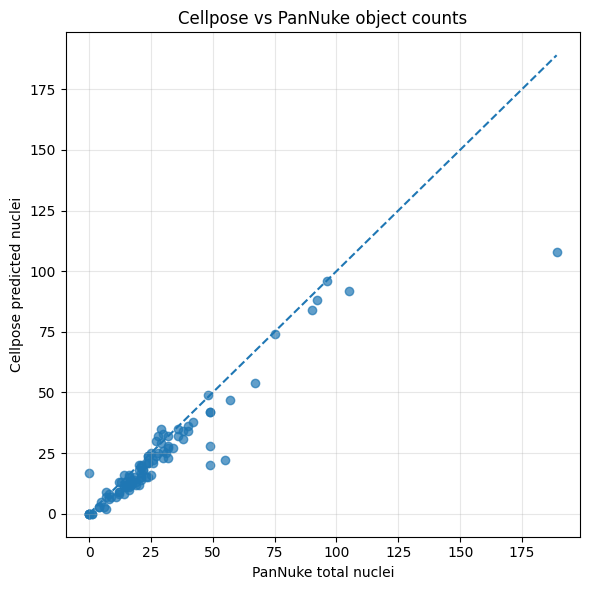

Saved figure: Fold_1/cellpose_fold1_analysis/figures/01_cellpose_vs_pannuke_object_counts.png


In [47]:
fig = plt.figure(figsize=(6, 6))
plt.scatter(
    image_results_df["pannuke_total_nuclei"],
    image_results_df["cellpose_nuclei"],
    alpha=0.7,
)
max_val = max(
    image_results_df["pannuke_total_nuclei"].max(),
    image_results_df["cellpose_nuclei"].max(),
)
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.xlabel("PanNuke total nuclei")
plt.ylabel("Cellpose predicted nuclei")
plt.title("Cellpose vs PanNuke object counts")
plt.grid(True, alpha=0.3)
save_fig("01_cellpose_vs_pannuke_object_counts", fig)


# 2. Neoplastic vs normal: pixel-level performance




In [48]:
pixel_compare = image_results_df[
    [
        "image_index",
        "tissue_type",
        "neoplastic_recall",
        "normal_recall",
        "neoplastic_dice",
        "normal_dice",
        "neoplastic_iou",
        "normal_iou",
    ]
].copy()

pixel_compare["recall_neoplastic_minus_normal"] = (
    pixel_compare["neoplastic_recall"] - pixel_compare["normal_recall"]
)

pixel_compare.describe().T


,count,mean,std,min,25%,50%,75%,max
image_index,100.0,1395.540000,730.870111,114.000000,846.750000,1380.000000,2018.000000,2635.000000
neoplastic_recall,100.0,0.382994,0.393121,0.000000,0.000000,0.171141,0.776759,0.945542
normal_recall,100.0,0.521680,0.330156,0.000000,0.207945,0.657613,0.778724,0.957442
neoplastic_dice,100.0,0.365750,0.393028,0.000000,0.000000,0.026270,0.795337,0.934912
normal_dice,100.0,0.428160,0.352242,0.000000,0.025436,0.438795,0.772035,0.918259
neoplastic_iou,100.0,0.303531,0.336656,0.000000,0.000000,0.013489,0.660227,0.877780
normal_iou,100.0,0.339061,0.302810,0.000000,0.012882,0.281567,0.628716,0.848872
recall_neoplastic_minus_normal,100.0,-0.138686,0.562437,-0.957442,-0.667474,-0.049202,0.116045,0.945542


/var/folders/t1/h1t65zld6258y1zfcl99y8vr0000gp/T/ipykernel_6061/285662966.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


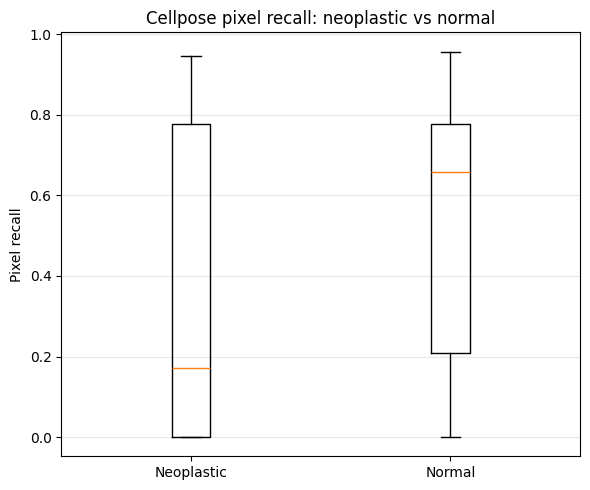

Saved figure: Fold_1/cellpose_fold1_analysis/figures/02_pixel_recall_neoplastic_vs_normal_boxplot.png


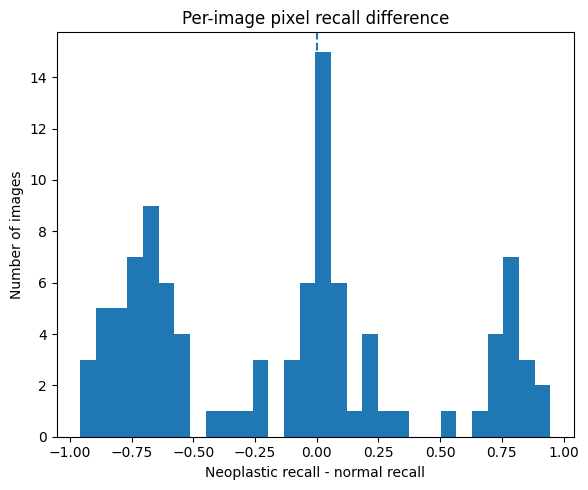

Saved figure: Fold_1/cellpose_fold1_analysis/figures/03_per_image_pixel_recall_difference_histogram.png


In [49]:
fig = plt.figure(figsize=(6, 5))
plt.boxplot(
    [
        image_results_df["neoplastic_recall"].dropna(),
        image_results_df["normal_recall"].dropna(),
    ],
    labels=["Neoplastic", "Normal"],
)
plt.ylabel("Pixel recall")
plt.title("Cellpose pixel recall: neoplastic vs normal")
plt.grid(True, axis="y", alpha=0.3)
save_fig("02_pixel_recall_neoplastic_vs_normal_boxplot", fig)

fig = plt.figure(figsize=(6, 5))
plt.hist(pixel_compare["recall_neoplastic_minus_normal"].dropna(), bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Neoplastic recall - normal recall")
plt.ylabel("Number of images")
plt.title("Per-image pixel recall difference")
save_fig("03_per_image_pixel_recall_difference_histogram", fig)


# 3. Neoplastic vs normal: object-level detection



A PanNuke nucleus is considered detected if it has a one-to-one Cellpose match with IoU above the threshold.

Thresholds:

- `0.10`: soft detection
- `0.25`: moderate detection
- `0.50`: strict detection


In [50]:
object_recall_rows = []

for thr in MATCH_IOU_THRESHOLDS:
    col = f"matched_iou_{thr}"

    for broad in ["neoplastic", "normal"]:
        sub = gt_objects_df[gt_objects_df["gt_broad_class"] == broad]
        object_recall_rows.append({
            "iou_threshold": thr,
            "class": broad,
            "n_gt_objects": len(sub),
            "n_detected": int(sub[col].sum()) if len(sub) > 0 else 0,
            "n_missed": int((~sub[col]).sum()) if len(sub) > 0 else 0,
            "object_recall": float(sub[col].mean()) if len(sub) > 0 else np.nan,
            "median_best_any_iou": float(sub["best_any_iou"].median()) if len(sub) > 0 else np.nan,
            "median_best_gt_overlap_fraction": float(sub["best_any_gt_overlap_fraction"].median()) if len(sub) > 0 else np.nan,
        })

object_recall_df = pd.DataFrame(object_recall_rows)
object_recall_df


,iou_threshold,class,n_gt_objects,n_detected,n_missed,object_recall,median_best_any_iou,median_best_gt_overlap_fraction
0,0.10,neoplastic,1144,893,251,0.780594,0.776393,0.810703
1,0.10,normal,1575,1202,373,0.763175,0.730924,0.784444
2,0.25,neoplastic,1144,887,257,0.775350,0.776393,0.810703
3,0.25,normal,1575,1196,379,0.759365,0.730924,0.784444
4,0.50,neoplastic,1144,842,302,0.736014,0.776393,0.810703
5,0.50,normal,1575,1115,460,0.707937,0.730924,0.784444


In [51]:
subtype_recall_rows = []

for thr in MATCH_IOU_THRESHOLDS:
    col = f"matched_iou_{thr}"

    for cname in ["neoplastic", "inflammatory", "connective", "dead", "epithelial"]:
        sub = gt_objects_df[gt_objects_df["gt_class"] == cname]
        subtype_recall_rows.append({
            "iou_threshold": thr,
            "class": cname,
            "broad_class": "neoplastic" if cname == "neoplastic" else "normal",
            "n_gt_objects": len(sub),
            "n_detected": int(sub[col].sum()) if len(sub) > 0 else 0,
            "n_missed": int((~sub[col]).sum()) if len(sub) > 0 else 0,
            "object_recall": float(sub[col].mean()) if len(sub) > 0 else np.nan,
            "median_area": float(sub["gt_area"].median()) if len(sub) > 0 else np.nan,
            "median_best_any_iou": float(sub["best_any_iou"].median()) if len(sub) > 0 else np.nan,
        })

subtype_recall_df = pd.DataFrame(subtype_recall_rows)
subtype_recall_df


,iou_threshold,class,broad_class,n_gt_objects,n_detected,n_missed,object_recall,median_area,median_best_any_iou
0,0.10,neoplastic,neoplastic,1144,893,251,0.780594,477.0,0.776393
1,0.10,inflammatory,normal,618,518,100,0.838188,260.5,0.766069
2,0.10,connective,normal,612,410,202,0.669935,344.0,0.659498
3,0.10,dead,normal,84,53,31,0.630952,85.5,0.573593
4,0.10,epithelial,normal,261,221,40,0.846743,411.0,0.750325
5,0.25,neoplastic,neoplastic,1144,887,257,0.775350,477.0,0.776393
6,0.25,inflammatory,normal,618,517,101,0.836570,260.5,0.766069
7,0.25,connective,normal,612,409,203,0.668301,344.0,0.659498
8,0.25,dead,normal,84,52,32,0.619048,85.5,0.573593
9,0.25,epithelial,normal,261,218,43,0.835249,411.0,0.750325


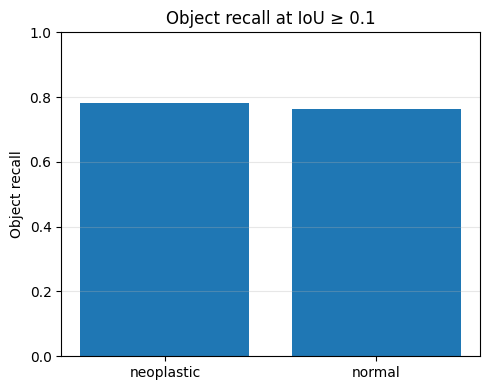

Saved figure: Fold_1/cellpose_fold1_analysis/figures/04_object_recall_iou_0.1.png


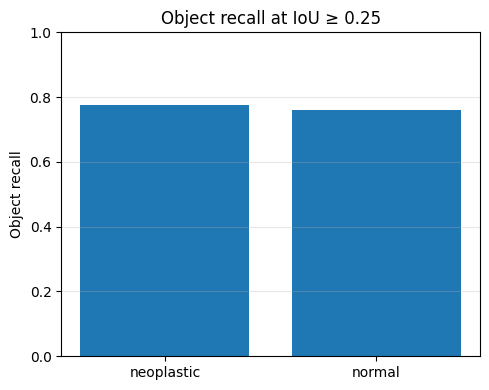

Saved figure: Fold_1/cellpose_fold1_analysis/figures/04_object_recall_iou_0.25.png


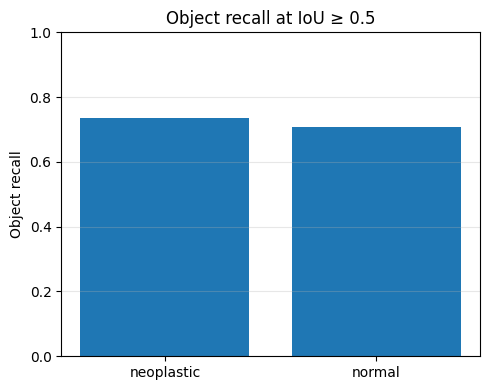

Saved figure: Fold_1/cellpose_fold1_analysis/figures/04_object_recall_iou_0.5.png


In [52]:
for thr in MATCH_IOU_THRESHOLDS:
    plot_df = object_recall_df[object_recall_df["iou_threshold"] == thr]

    fig = plt.figure(figsize=(5, 4))
    plt.bar(plot_df["class"], plot_df["object_recall"])
    plt.ylim(0, 1)
    plt.ylabel("Object recall")
    plt.title(f"Object recall at IoU ≥ {thr}")
    plt.grid(True, axis="y", alpha=0.3)
    save_fig(f"04_object_recall_iou_{thr}", fig)


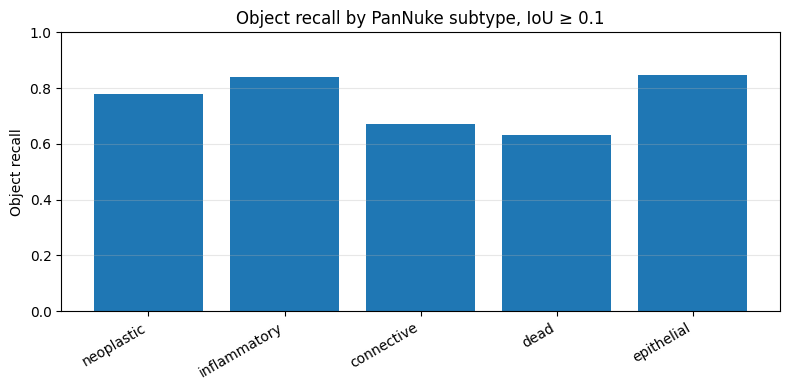

Saved figure: Fold_1/cellpose_fold1_analysis/figures/05_object_recall_by_pannuke_subtype_iou_0.1.png


In [53]:
thr = PRIMARY_MATCH_IOU
plot_df = subtype_recall_df[subtype_recall_df["iou_threshold"] == thr].copy()

fig = plt.figure(figsize=(8, 4))
plt.bar(plot_df["class"], plot_df["object_recall"])
plt.ylim(0, 1)
plt.ylabel("Object recall")
plt.title(f"Object recall by PanNuke subtype, IoU ≥ {thr}")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
save_fig(f"05_object_recall_by_pannuke_subtype_iou_{thr}", fig)


# 4. Missed nuclei analysis

This compares detected vs missed PanNuke objects based on size, shape, tissue type



In [54]:
primary_col = f"matched_iou_{PRIMARY_MATCH_IOU}"

missed_summary = (
    gt_objects_df
    .assign(status=np.where(gt_objects_df[primary_col], "detected", "missed"))
    .groupby(["gt_broad_class", "status"])
    .agg(
        n_objects=("gt_uid", "count"),
        median_area=("gt_area", "median"),
        mean_area=("gt_area", "mean"),
        median_eccentricity=("gt_eccentricity", "median"),
        median_solidity=("gt_solidity", "median"),
        median_best_iou=("best_any_iou", "median"),
        median_best_gt_overlap_fraction=("best_any_gt_overlap_fraction", "median"),
    )
    .reset_index()
)

missed_summary


,gt_broad_class,status,n_objects,median_area,mean_area,median_eccentricity,median_solidity,median_best_iou,median_best_gt_overlap_fraction
0,neoplastic,detected,893,557.0,631.658455,0.726275,0.964752,0.814935,0.851220
1,neoplastic,missed,251,172.0,250.637450,0.876028,0.950820,0.000000,0.000000
2,normal,detected,1202,334.0,416.327787,0.740224,0.958305,0.783694,0.822619
3,normal,missed,373,126.0,197.018767,0.832954,0.951613,0.000000,0.000000


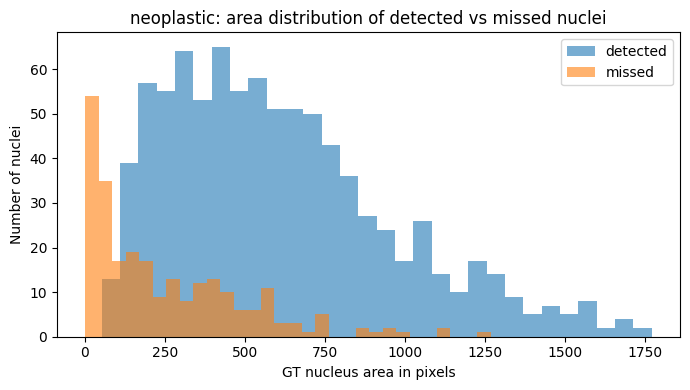

Saved figure: Fold_1/cellpose_fold1_analysis/figures/06_neoplastic_detected_vs_missed_area_distribution.png


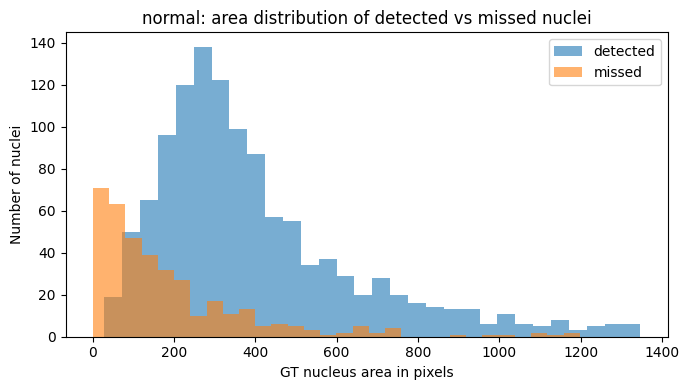

Saved figure: Fold_1/cellpose_fold1_analysis/figures/06_normal_detected_vs_missed_area_distribution.png


In [55]:
for broad in ["neoplastic", "normal"]:
    sub = gt_objects_df[gt_objects_df["gt_broad_class"] == broad].copy()
    if len(sub) == 0:
        continue

    detected = sub.loc[sub[primary_col], "gt_area"]
    missed = sub.loc[~sub[primary_col], "gt_area"]
    max_clip = sub["gt_area"].quantile(0.99)

    fig = plt.figure(figsize=(7, 4))

    if len(detected) > 0:
        plt.hist(detected[detected <= max_clip], bins=30, alpha=0.6, label="detected")

    if len(missed) > 0:
        plt.hist(missed[missed <= max_clip], bins=30, alpha=0.6, label="missed")

    plt.xlabel("GT nucleus area in pixels")
    plt.ylabel("Number of nuclei")
    plt.title(f"{broad}: area distribution of detected vs missed nuclei")
    plt.legend()
    save_fig(f"06_{broad}_detected_vs_missed_area_distribution", fig)


In [56]:
size_df = gt_objects_df.copy()
size_df["size_bin"] = pd.qcut(size_df["gt_area"], q=4, duplicates="drop")

size_miss_rate = (
    size_df
    .groupby(["gt_broad_class", "size_bin"], observed=True)
    .agg(
        n_objects=("gt_uid", "count"),
        miss_rate=(primary_col, lambda x: float((~x).mean())),
        median_area=("gt_area", "median"),
    )
    .reset_index()
)

size_miss_rate


,gt_broad_class,size_bin,n_objects,miss_rate,median_area
0,neoplastic,"(0.999, 199.0]",213,0.624413,104.0
1,neoplastic,"(199.0, 345.0]",199,0.216080,273.0
2,neoplastic,"(345.0, 590.0]",304,0.177632,464.0
3,neoplastic,"(590.0, 3433.0]",428,0.049065,847.5
4,normal,"(0.999, 199.0]",469,0.537313,111.0
5,normal,"(199.0, 345.0]",481,0.126819,273.0
6,normal,"(345.0, 590.0]",374,0.098930,428.5
7,normal,"(590.0, 3433.0]",251,0.091633,807.0


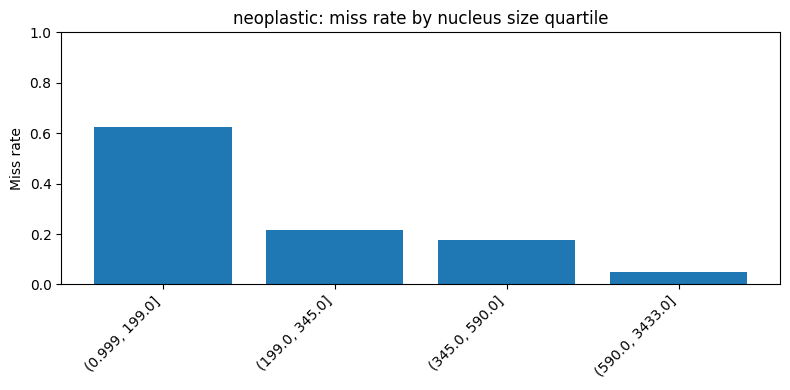

Saved figure: Fold_1/cellpose_fold1_analysis/figures/07_neoplastic_miss_rate_by_size_quartile.png


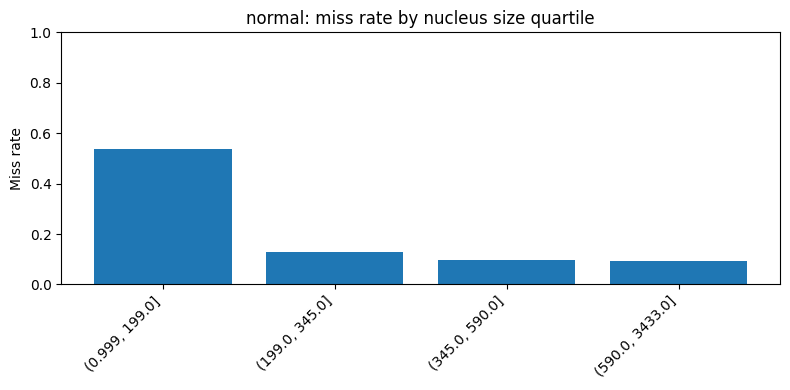

Saved figure: Fold_1/cellpose_fold1_analysis/figures/07_normal_miss_rate_by_size_quartile.png


In [57]:
for broad in ["neoplastic", "normal"]:
    sub = size_miss_rate[size_miss_rate["gt_broad_class"] == broad]
    if len(sub) == 0:
        continue

    fig = plt.figure(figsize=(8, 4))
    plt.bar(sub["size_bin"].astype(str), sub["miss_rate"])
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Miss rate")
    plt.title(f"{broad}: miss rate by nucleus size quartile")
    save_fig(f"07_{broad}_miss_rate_by_size_quartile", fig)


# 5. Cellpose predicted-object purity




In [58]:
pred_class_summary = (
    pred_objects_df
    .groupby("pred_assigned_class")
    .agg(
        n_pred_objects=("pred_uid", "count"),
        median_area=("pred_area", "median"),
        mean_area=("pred_area", "mean"),
        median_any_gt_overlap_fraction=("pred_any_gt_overlap_fraction", "median"),
        median_cancer_overlap_fraction=("pred_cancer_overlap_fraction", "median"),
        median_normal_overlap_fraction=("pred_normal_overlap_fraction", "median"),
    )
    .reset_index()
    .sort_values("n_pred_objects", ascending=False)
)

pred_class_summary


,pred_assigned_class,n_pred_objects,median_area,mean_area,median_any_gt_overlap_fraction,median_cancer_overlap_fraction,median_normal_overlap_fraction
1,normal_like,1216,277.0,357.657072,0.988434,0.000000,0.988397
0,neoplastic_like,898,483.5,569.083519,0.992918,0.992918,0.000000
2,unmatched,158,167.0,238.746835,0.000000,0.000000,0.000000


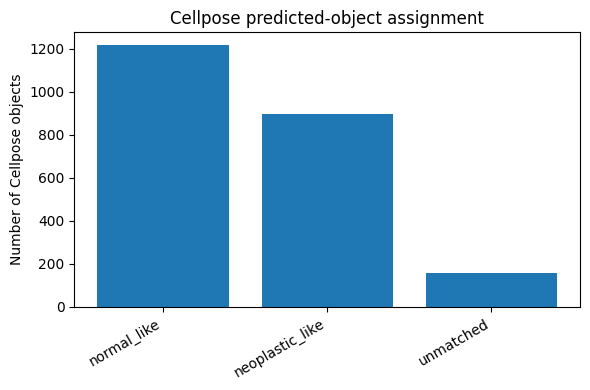

Saved figure: Fold_1/cellpose_fold1_analysis/figures/08_cellpose_predicted_object_assignment.png


In [59]:
fig = plt.figure(figsize=(6, 4))
plt.bar(pred_class_summary["pred_assigned_class"], pred_class_summary["n_pred_objects"])
plt.ylabel("Number of Cellpose objects")
plt.title("Cellpose predicted-object assignment")
plt.xticks(rotation=30, ha="right")
save_fig("08_cellpose_predicted_object_assignment", fig)


# 6. Tissue-type analysis

This checks whether the neoplastic-vs-normal difference depends on tissue type.


In [60]:
by_tissue = (
    image_results_df
    .groupby("tissue_type")
    .agg(
        n_images=("image_index", "count"),
        mean_pannuke_total=("pannuke_total_nuclei", "mean"),
        mean_pannuke_neoplastic=("pannuke_neoplastic_nuclei", "mean"),
        mean_pannuke_normal=("pannuke_normal_nuclei", "mean"),
        mean_cellpose=("cellpose_nuclei", "mean"),
        mean_all_dice=("all_dice", "mean"),
        mean_neoplastic_pixel_recall=("neoplastic_recall", "mean"),
        mean_normal_pixel_recall=("normal_recall", "mean"),
        mean_neoplastic_object_recall=(f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}", "mean"),
        mean_normal_object_recall=(f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}", "mean"),
        mean_pred_unmatched=("pred_unmatched", "mean"),
    )
    .reset_index()
)

by_tissue["object_recall_neoplastic_minus_normal"] = (
    by_tissue["mean_neoplastic_object_recall"] - by_tissue["mean_normal_object_recall"]
)

by_tissue.sort_values("object_recall_neoplastic_minus_normal")


,tissue_type,n_images,mean_pannuke_total,mean_pannuke_neoplastic,mean_pannuke_normal,mean_cellpose,mean_all_dice,mean_neoplastic_pixel_recall,mean_normal_pixel_recall,mean_neoplastic_object_recall,mean_normal_object_recall,mean_pred_unmatched,object_recall_neoplastic_minus_normal
0,Adrenal_gland,2,16.500000,14.500000,2.000000,11.500000,0.811785,0.694076,0.751892,0.665789,1.000000,0.000000,-0.334211
11,Ovarian,2,15.000000,2.500000,12.500000,12.000000,0.739990,0.452316,0.726800,0.500000,0.737013,1.500000,-0.237013
5,Colon,19,32.421053,4.210526,28.210526,21.473684,0.613696,0.052659,0.518457,0.420077,0.619490,0.894737,-0.199413
16,Testis,4,48.500000,7.000000,41.500000,44.000000,0.845422,0.353814,0.850041,0.701754,0.867394,2.000000,-0.165640
15,Stomach,2,36.000000,22.000000,14.000000,31.500000,0.852225,0.764147,0.777119,0.784188,0.892857,1.500000,-0.108669
14,Skin,1,96.000000,38.000000,58.000000,96.000000,0.809535,0.686797,0.750999,0.789474,0.879310,8.000000,-0.089837
17,Thyroid,2,23.000000,10.500000,12.500000,21.000000,0.825531,0.813035,0.826165,0.900000,0.956522,1.000000,-0.056522
6,Esophagus,5,19.400000,9.600000,9.800000,17.200000,0.880573,0.529271,0.640900,0.888889,0.888919,0.600000,-0.000031
2,Bladder,3,15.333333,10.000000,5.333333,11.666667,0.863525,0.282765,0.504631,0.766667,0.750000,0.000000,0.016667
3,Breast,24,22.666667,10.583333,12.083333,19.958333,0.817942,0.447056,0.505969,0.785789,0.764298,0.958333,0.021491


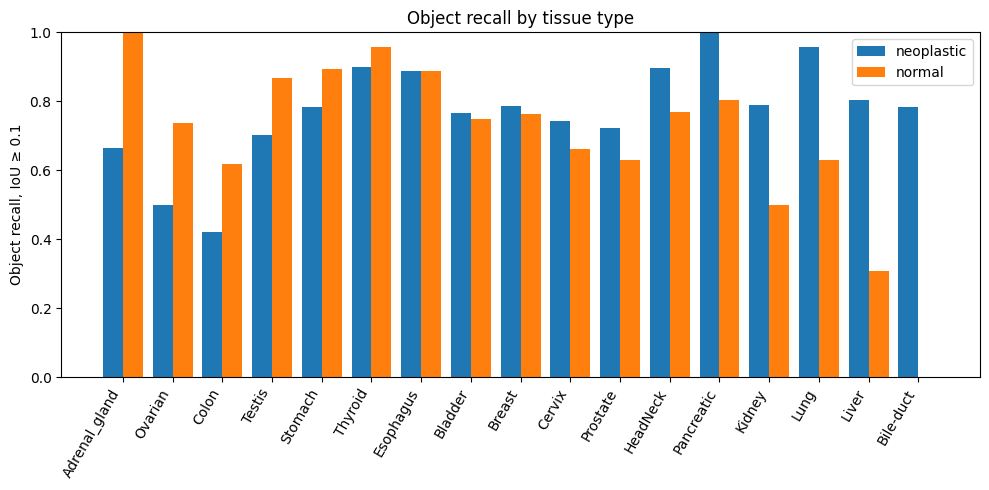

Saved figure: Fold_1/cellpose_fold1_analysis/figures/09_object_recall_by_tissue_type.png


In [61]:
plot_df = by_tissue[by_tissue["n_images"] >= 2].copy()
plot_df = plot_df.sort_values("object_recall_neoplastic_minus_normal")

fig = plt.figure(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.4

plt.bar(x - width / 2, plot_df["mean_neoplastic_object_recall"], width, label="neoplastic")
plt.bar(x + width / 2, plot_df["mean_normal_object_recall"], width, label="normal")

plt.ylim(0, 1)
plt.xticks(x, plot_df["tissue_type"], rotation=60, ha="right")
plt.ylabel(f"Object recall, IoU ≥ {PRIMARY_MATCH_IOU}")
plt.title("Object recall by tissue type")
plt.legend()
save_fig("09_object_recall_by_tissue_type", fig)


# 7. statistical comparison

This compares per-image neoplastic vs normal object recall. Only images containing both neoplastic and normal nuclei are used.


In [62]:
paired_cols = [
    "image_index",
    "tissue_type",
    f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}",
    f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}",
    "pannuke_neoplastic_nuclei",
    "pannuke_normal_nuclei",
]

paired = image_results_df[paired_cols].copy()
paired = paired[
    (paired["pannuke_neoplastic_nuclei"] > 0)
    & (paired["pannuke_normal_nuclei"] > 0)
].copy()

paired["neoplastic_minus_normal_object_recall"] = (
    paired[f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}"]
    - paired[f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}"]
)

print("Number of paired images:", len(paired))
paired["neoplastic_minus_normal_object_recall"].describe()


Number of paired images: 40


count    40.000000
mean      0.056052
std       0.363520
min      -0.545455
25%      -0.190625
50%      -0.012439
75%       0.164881
max       0.900000
Name: neoplastic_minus_normal_object_recall, dtype: float64

In [63]:
if SCIPY_AVAILABLE and len(paired) > 0:
    stat, pval = wilcoxon(
        paired[f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}"],
        paired[f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}"],
        zero_method="wilcox",
        alternative="two-sided",
    )

    print(f"Wilcoxon paired test, IoU ≥ {PRIMARY_MATCH_IOU}")
    print("statistic:", stat)
    print("p-value:", pval)
else:
    print("Statistical test skipped: scipy unavailable or no paired images.")


Wilcoxon paired test, IoU ≥ 0.1
statistic: 404.5
p-value: 0.9410663713580362


# 8. plots




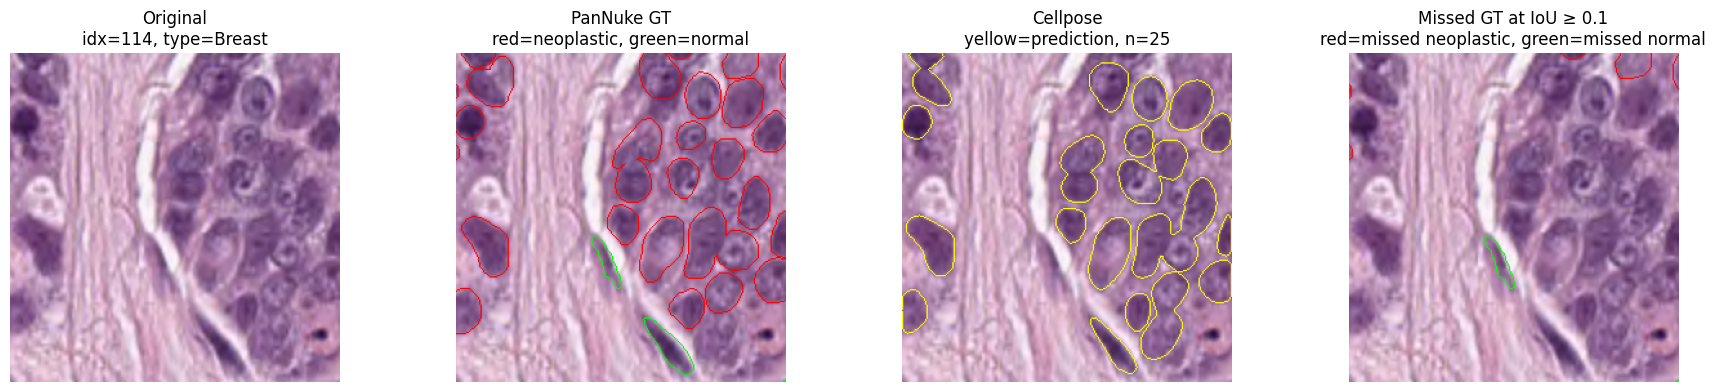

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_114_iou_0.1.png


,value
image_index,114
tissue_type,Breast
pannuke_total_nuclei,31
pannuke_neoplastic_nuclei,28
pannuke_normal_nuclei,3
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.083333
mean_gts_per_pred,1.083333
gt_with_multiple_preds,2


In [64]:
def show_example_detailed(idx, iou_threshold=PRIMARY_MATCH_IOU, save=True, show_table=True):
    """Visualize one image with GT classes, Cellpose boundaries, and missed objects."""
    img = normalize_to_uint8(images[idx])
    gt_mask = masks[idx]
    cp_mask = pred_masks[int(idx)]

    gt_cancer = pannuke_cancer_mask(gt_mask)
    gt_normal = pannuke_normal_mask(gt_mask)

    cancer_boundaries = find_boundaries(gt_cancer, mode="outer")
    normal_boundaries = find_boundaries(gt_normal, mode="outer")
    cp_boundaries = find_boundaries(cp_mask > 0, mode="outer")

    class_overlay = img.copy()
    class_overlay[cancer_boundaries] = [255, 0, 0]
    class_overlay[normal_boundaries] = [0, 255, 0]

    cp_overlay = img.copy()
    cp_overlay[cp_boundaries] = [255, 255, 0]

    img_gt = gt_objects_df[gt_objects_df["image_index"] == idx].copy()
    col = f"matched_iou_{iou_threshold}"

    missed_neoplastic = img_gt[
        (img_gt["gt_broad_class"] == "neoplastic")
        & (~img_gt[col])
    ]
    missed_normal = img_gt[
        (img_gt["gt_broad_class"] == "normal")
        & (~img_gt[col])
    ]

    missed_overlay = img.copy()

    for _, row in missed_neoplastic.iterrows():
        ch = int(row["gt_channel"])
        oid = int(row["gt_original_id"])
        obj = gt_mask[..., ch] == oid
        b = find_boundaries(obj, mode="outer")
        missed_overlay[b] = [255, 0, 0]

    for _, row in missed_normal.iterrows():
        ch = int(row["gt_channel"])
        oid = int(row["gt_original_id"])
        obj = gt_mask[..., ch] == oid
        b = find_boundaries(obj, mode="outer")
        missed_overlay[b] = [0, 255, 0]

    result_row = image_results_df[image_results_df["image_index"] == idx].iloc[0]

    fig = plt.figure(figsize=(18, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title(f"Original\nidx={idx}, type={types[idx]}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(class_overlay)
    plt.title("PanNuke GT\nred=neoplastic, green=normal")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(cp_overlay)
    plt.title(f"Cellpose\nyellow=prediction, n={int(result_row['cellpose_nuclei'])}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(missed_overlay)
    plt.title(f"Missed GT at IoU ≥ {iou_threshold}\nred=missed neoplastic, green=missed normal")
    plt.axis("off")

    if save:
        save_fig(f"10_visual_inspection_idx_{idx}_iou_{iou_threshold}", fig)
    else:
        plt.show()
        plt.close(fig)

    if show_table:
        display(result_row.to_frame("value"))


show_example_detailed(int(selected_indices[0]))


Worst neoplastic object recall examples: [972, 1806, 2602, 2635, 588]


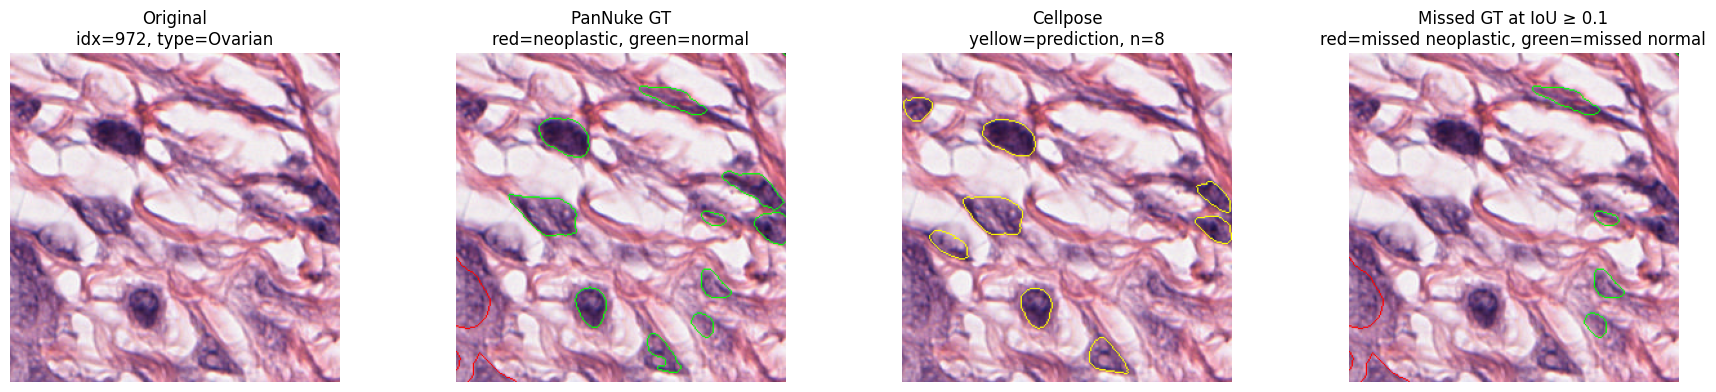

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_972_iou_0.1.png


,value
image_index,972
tissue_type,Ovarian
pannuke_total_nuclei,14
pannuke_neoplastic_nuclei,3
pannuke_normal_nuclei,11
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.0
gt_with_multiple_preds,0


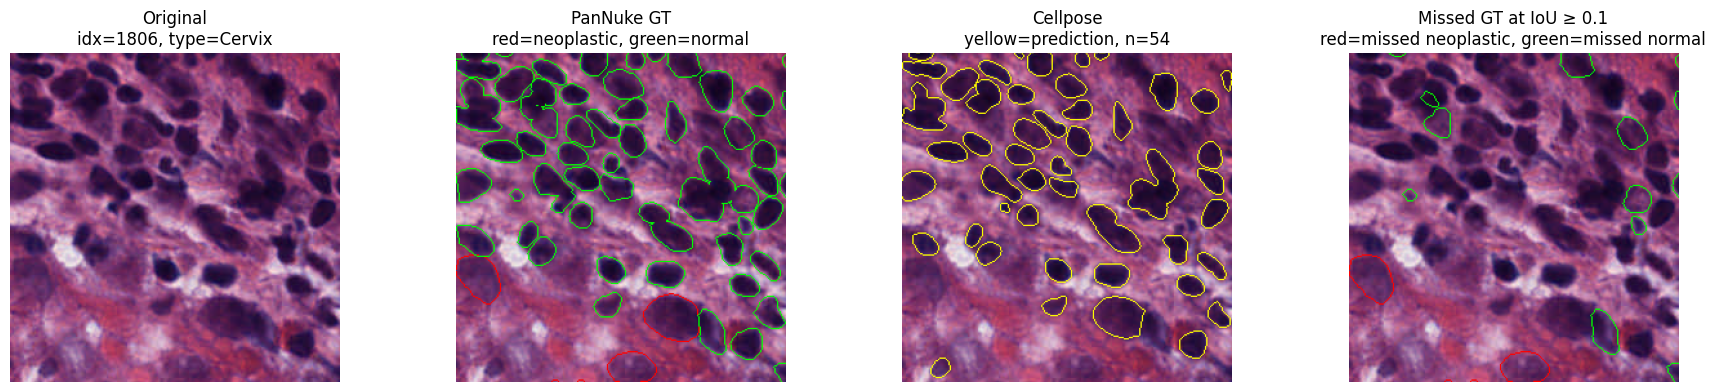

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1806_iou_0.1.png


,value
image_index,1806
tissue_type,Cervix
pannuke_total_nuclei,67
pannuke_neoplastic_nuclei,4
pannuke_normal_nuclei,63
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.115385
mean_gts_per_pred,1.137255
gt_with_multiple_preds,6


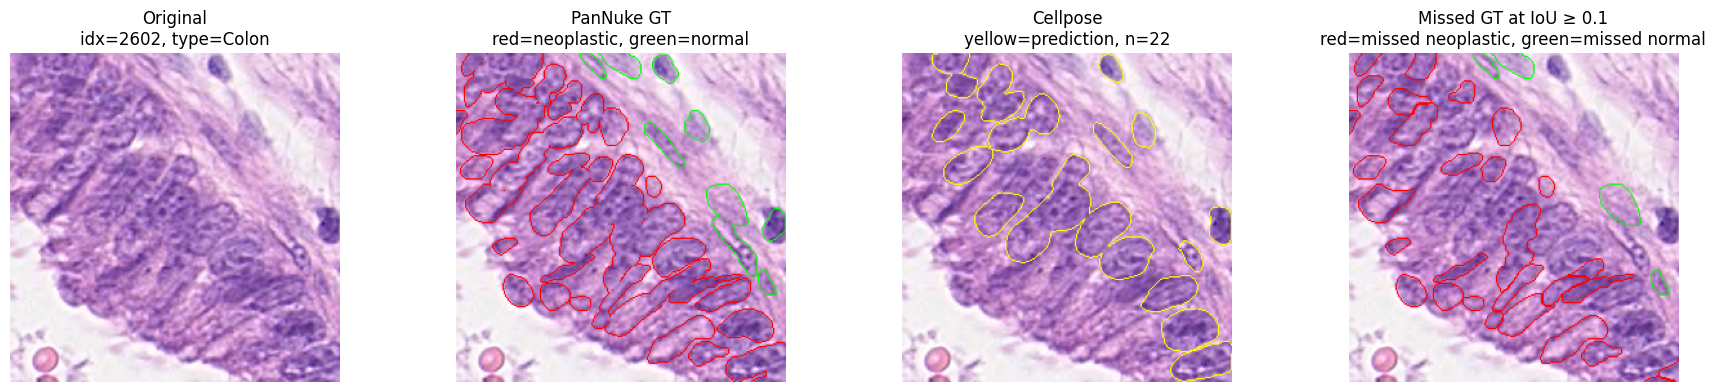

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_2602_iou_0.1.png


,value
image_index,2602
tissue_type,Colon
pannuke_total_nuclei,55
pannuke_neoplastic_nuclei,46
pannuke_normal_nuclei,9
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.25
mean_gts_per_pred,1.818182
gt_with_multiple_preds,8


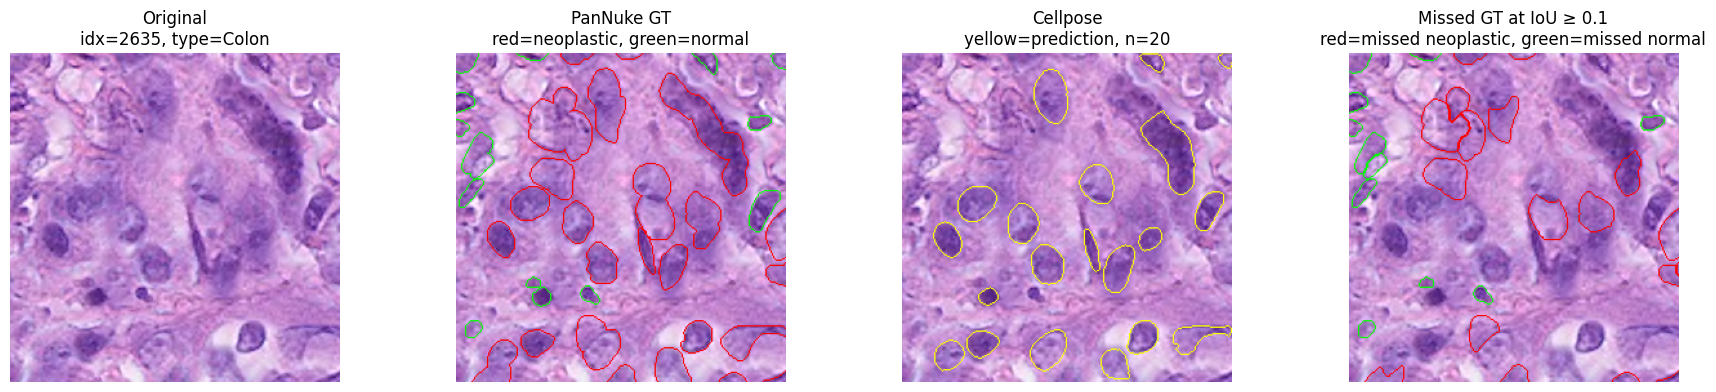

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_2635_iou_0.1.png


,value
image_index,2635
tissue_type,Colon
pannuke_total_nuclei,49
pannuke_neoplastic_nuclei,34
pannuke_normal_nuclei,15
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.2
gt_with_multiple_preds,0


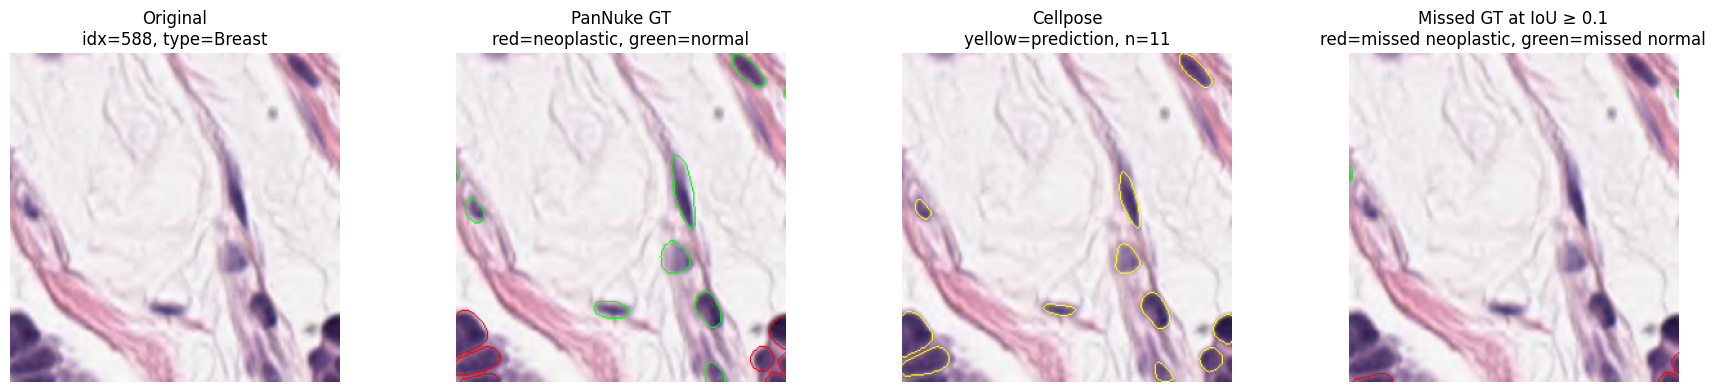

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_588_iou_0.1.png


,value
image_index,588
tissue_type,Breast
pannuke_total_nuclei,16
pannuke_neoplastic_nuclei,7
pannuke_normal_nuclei,9
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.0
gt_with_multiple_preds,0


In [65]:
worst_neoplastic = (
    image_results_df[image_results_df["pannuke_neoplastic_nuclei"] > 0]
    .sort_values(f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}", ascending=True)
    .head(5)["image_index"]
    .tolist()
)

print("Worst neoplastic object recall examples:", worst_neoplastic)

for idx in worst_neoplastic:
    show_example_detailed(int(idx))


Worst normal object recall examples: [2199, 2198, 1890, 1639, 1165]


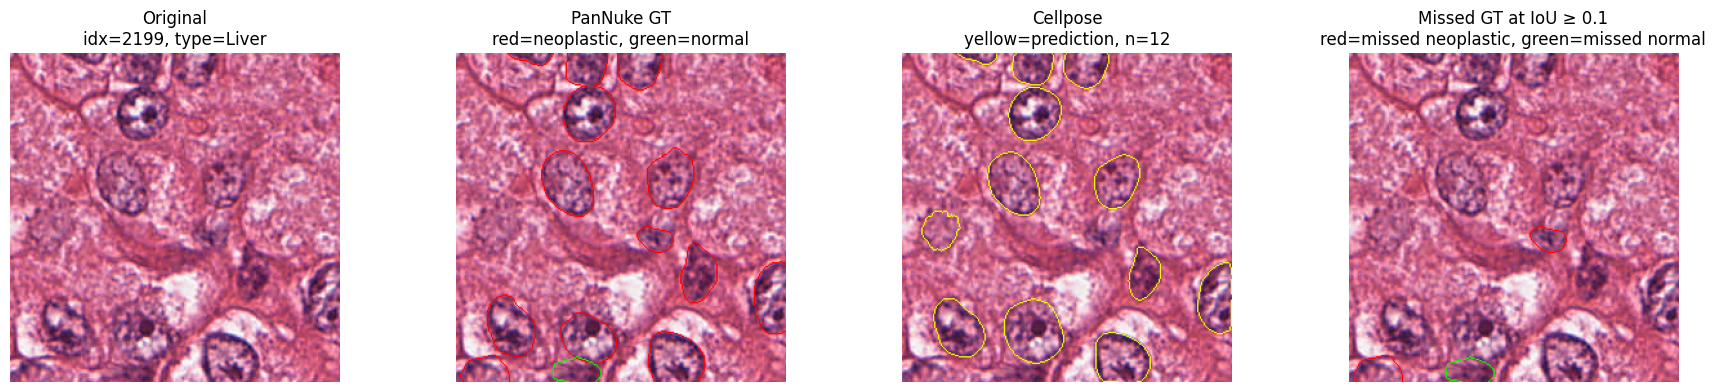

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_2199_iou_0.1.png


,value
image_index,2199
tissue_type,Liver
pannuke_total_nuclei,14
pannuke_neoplastic_nuclei,13
pannuke_normal_nuclei,1
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.0
gt_with_multiple_preds,0


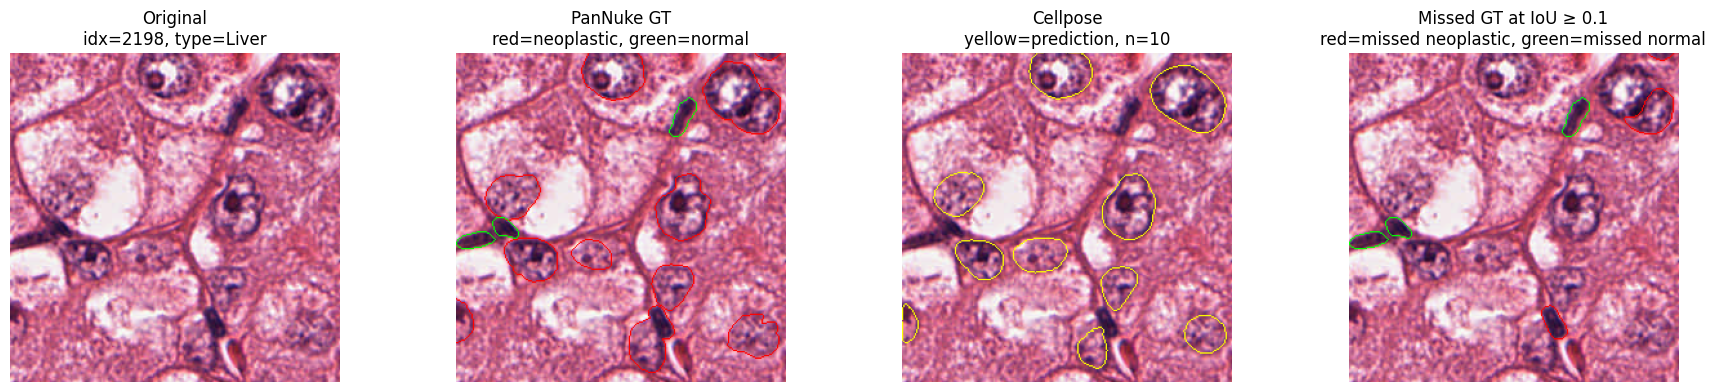

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_2198_iou_0.1.png


,value
image_index,2198
tissue_type,Liver
pannuke_total_nuclei,16
pannuke_neoplastic_nuclei,13
pannuke_normal_nuclei,3
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.1
gt_with_multiple_preds,0


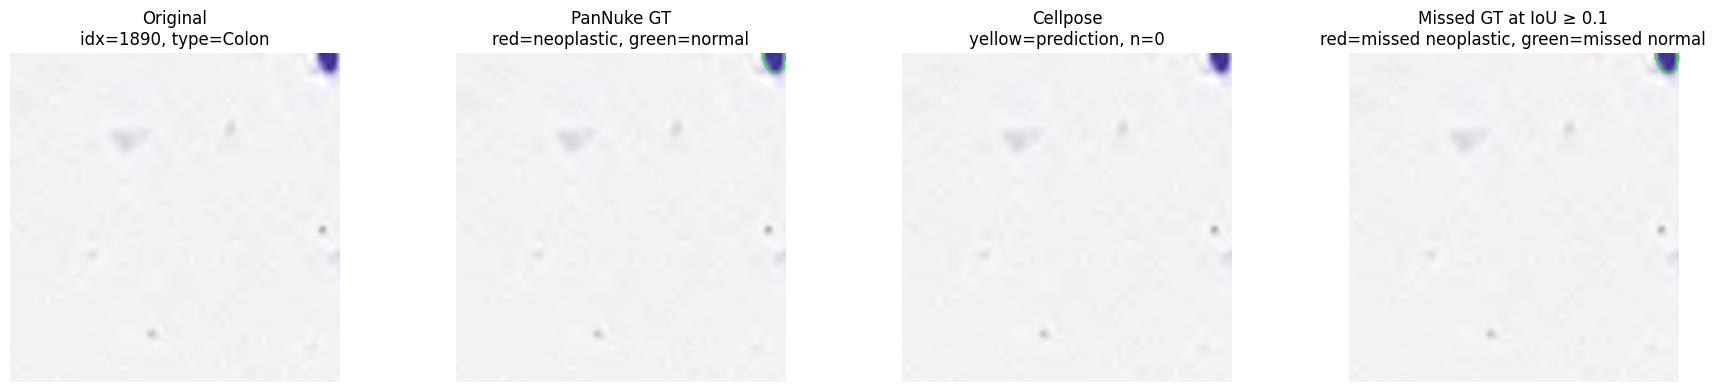

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1890_iou_0.1.png


,value
image_index,1890
tissue_type,Colon
pannuke_total_nuclei,1
pannuke_neoplastic_nuclei,0
pannuke_normal_nuclei,1
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,NaN
mean_gts_per_pred,NaN
gt_with_multiple_preds,0


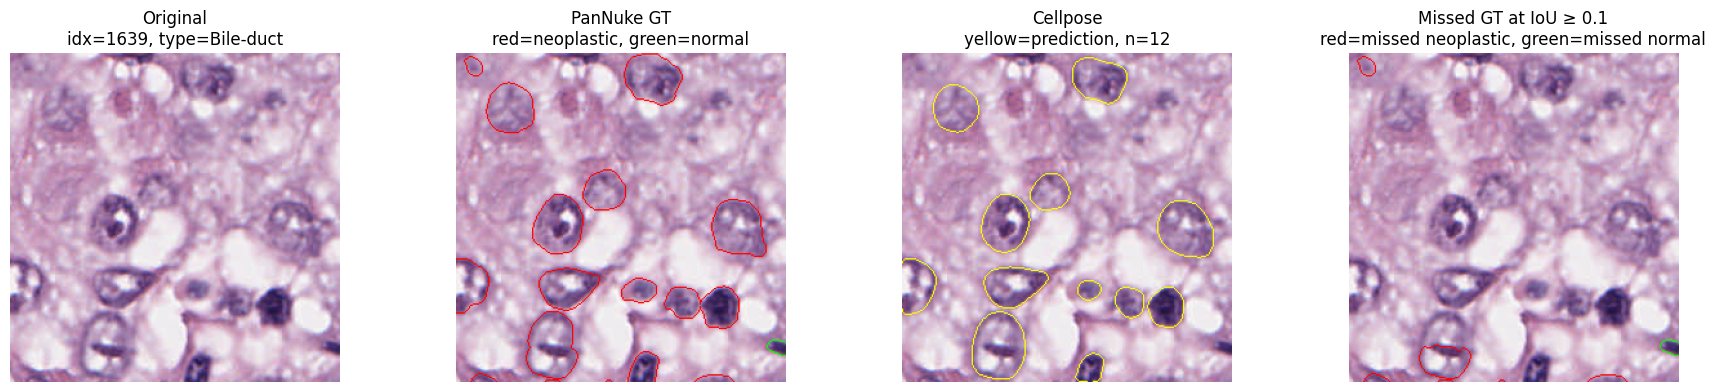

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1639_iou_0.1.png


,value
image_index,1639
tissue_type,Bile-duct
pannuke_total_nuclei,19
pannuke_neoplastic_nuclei,18
pannuke_normal_nuclei,1
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.083333
gt_with_multiple_preds,0


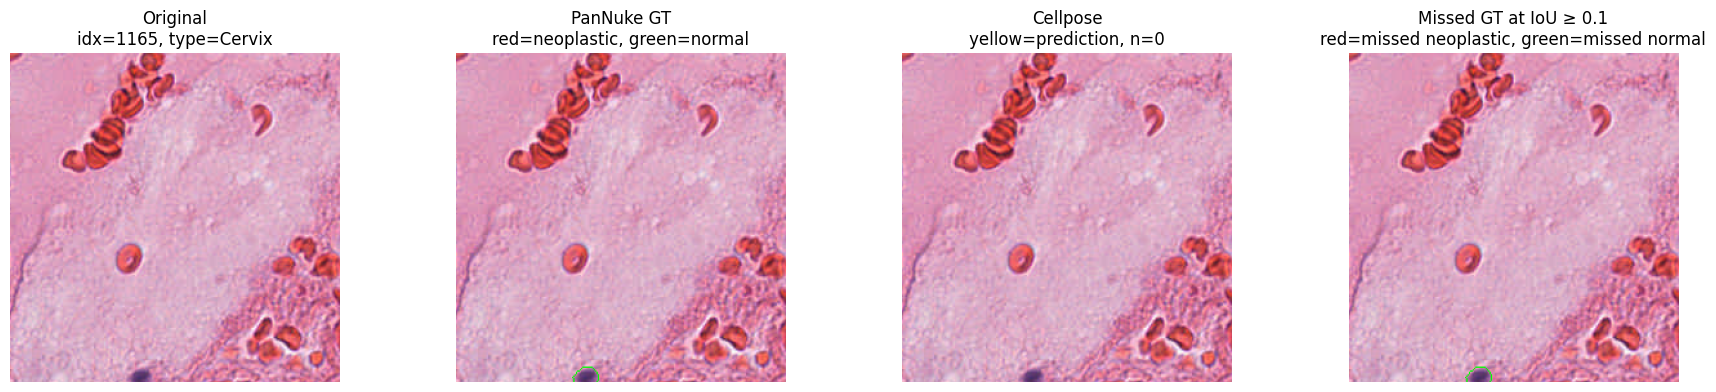

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1165_iou_0.1.png


,value
image_index,1165
tissue_type,Cervix
pannuke_total_nuclei,1
pannuke_neoplastic_nuclei,0
pannuke_normal_nuclei,1
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,NaN
mean_gts_per_pred,NaN
gt_with_multiple_preds,0


In [66]:
worst_normal = (
    image_results_df[image_results_df["pannuke_normal_nuclei"] > 0]
    .sort_values(f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}", ascending=True)
    .head(5)["image_index"]
    .tolist()
)

print("Worst normal object recall examples:", worst_normal)

for idx in worst_normal:
    show_example_detailed(int(idx))


Images where neoplastic detection is worse than normal: [972, 1806, 1218, 1217, 955]


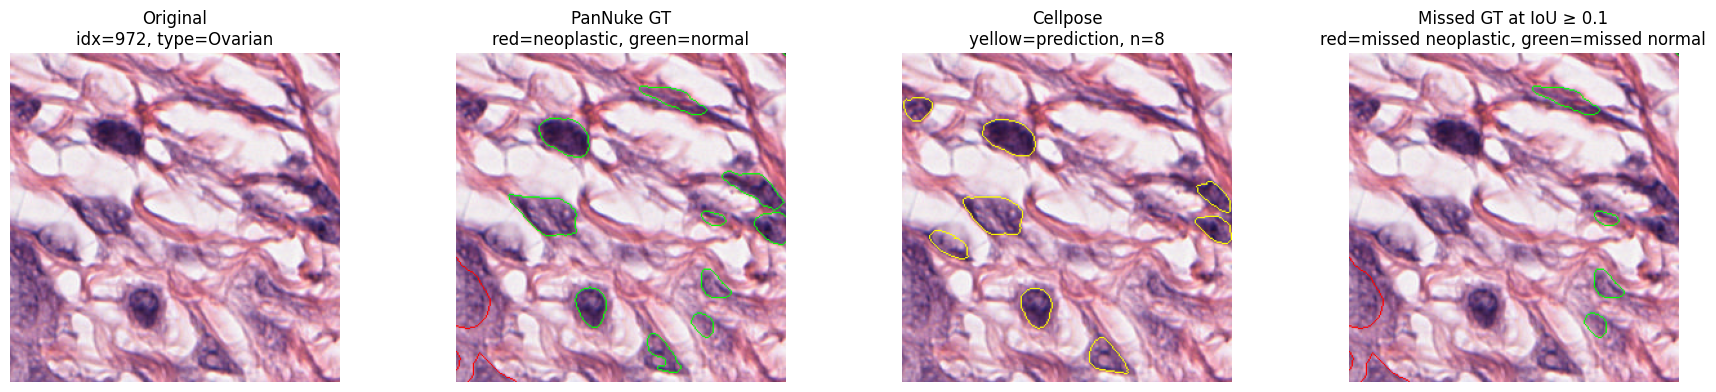

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_972_iou_0.1.png


,value
image_index,972
tissue_type,Ovarian
pannuke_total_nuclei,14
pannuke_neoplastic_nuclei,3
pannuke_normal_nuclei,11
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.0
gt_with_multiple_preds,0


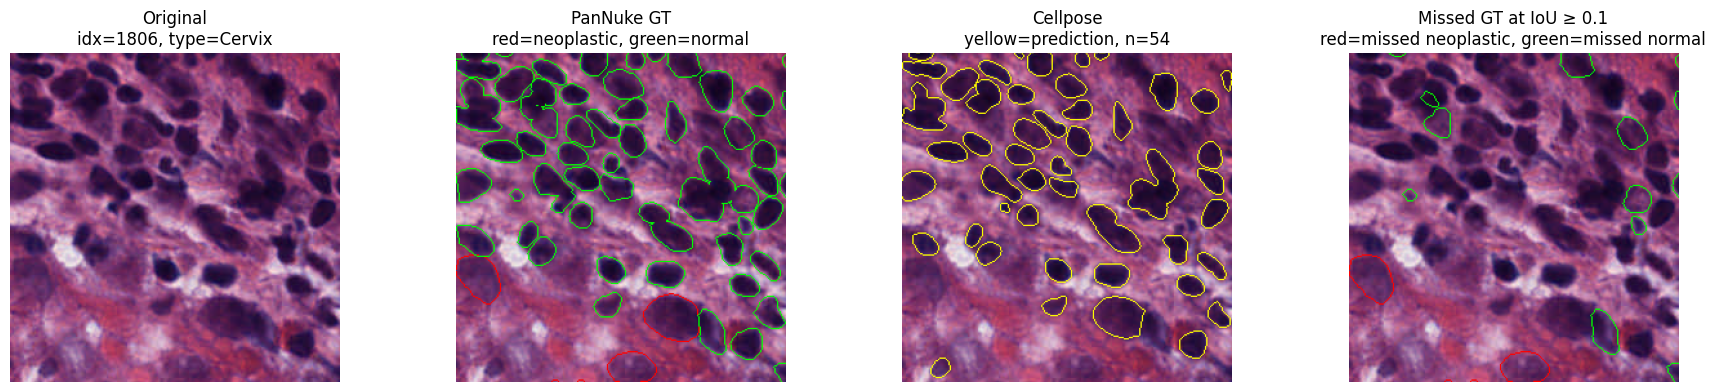

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1806_iou_0.1.png


,value
image_index,1806
tissue_type,Cervix
pannuke_total_nuclei,67
pannuke_neoplastic_nuclei,4
pannuke_normal_nuclei,63
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.115385
mean_gts_per_pred,1.137255
gt_with_multiple_preds,6


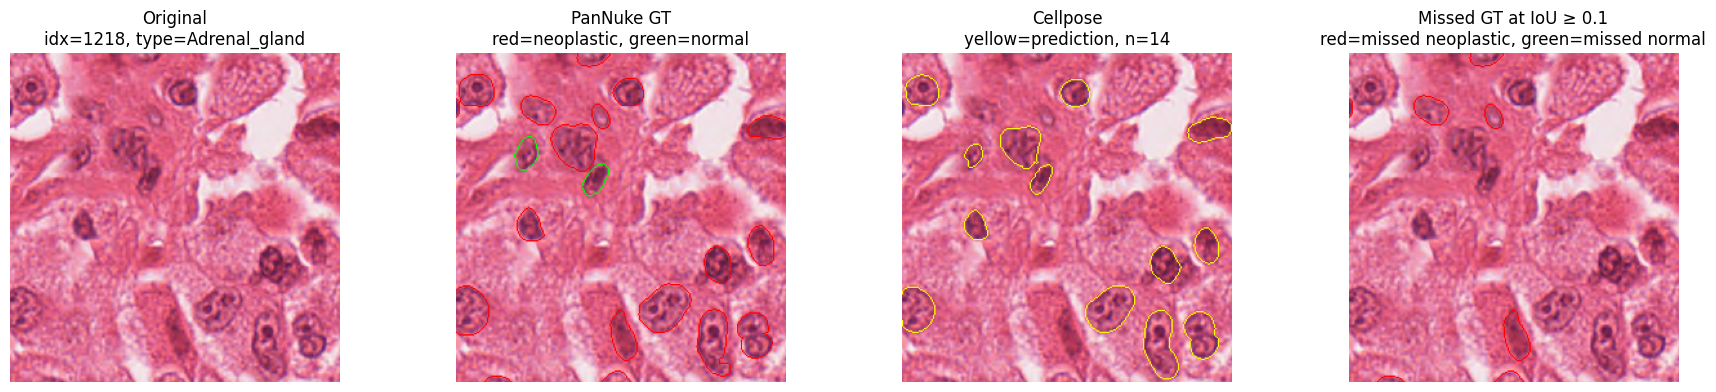

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1218_iou_0.1.png


,value
image_index,1218
tissue_type,Adrenal_gland
pannuke_total_nuclei,21
pannuke_neoplastic_nuclei,19
pannuke_normal_nuclei,2
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.071429
mean_gts_per_pred,1.071429
gt_with_multiple_preds,1


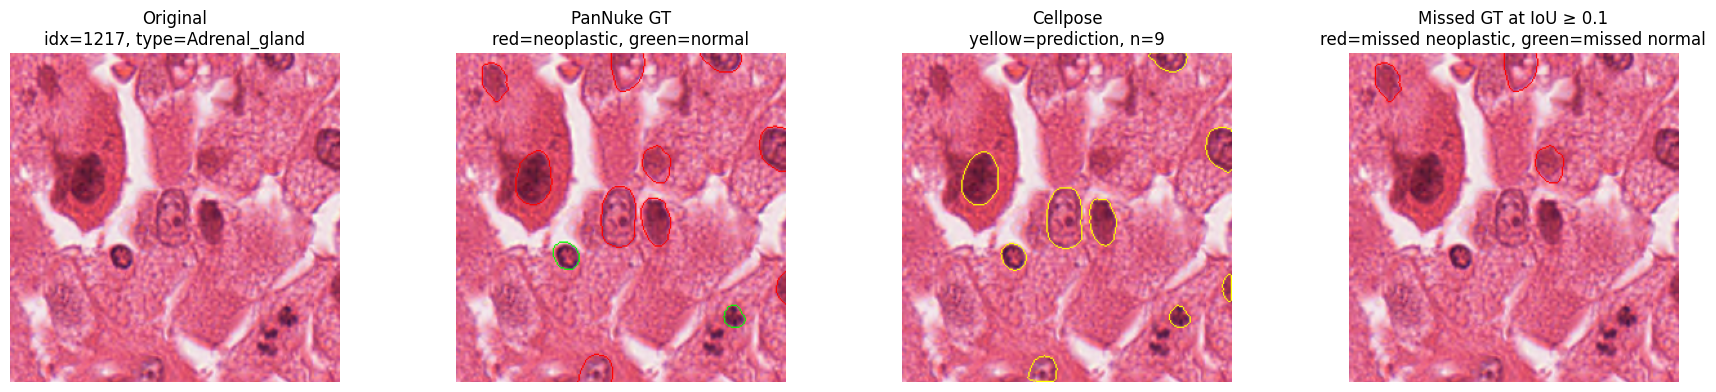

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_1217_iou_0.1.png


,value
image_index,1217
tissue_type,Adrenal_gland
pannuke_total_nuclei,12
pannuke_neoplastic_nuclei,10
pannuke_normal_nuclei,2
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.0
mean_gts_per_pred,1.0
gt_with_multiple_preds,0


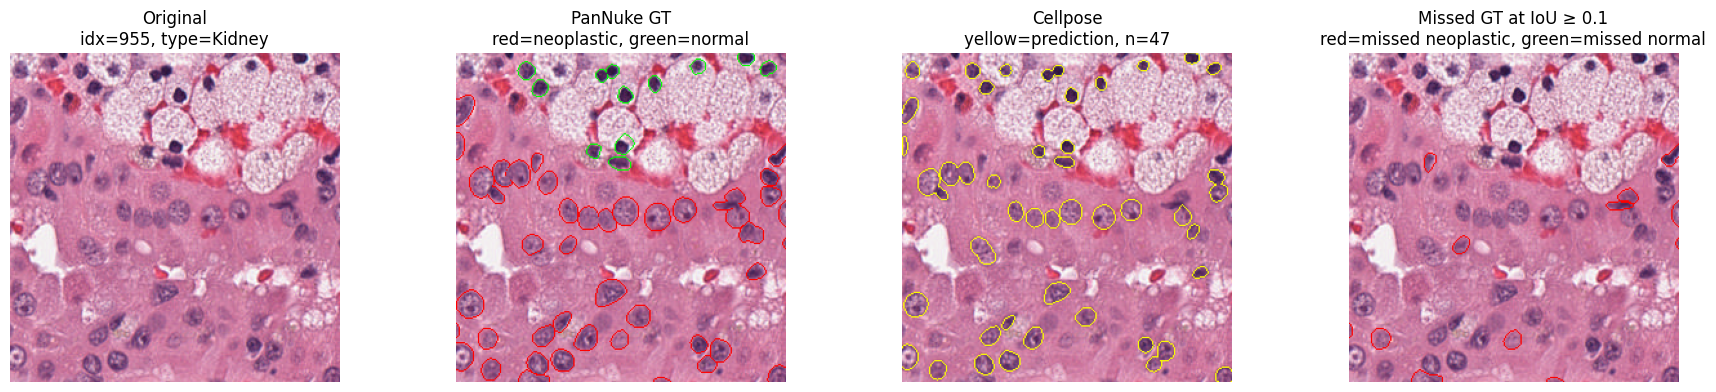

Saved figure: Fold_1/cellpose_fold1_analysis/figures/10_visual_inspection_idx_955_iou_0.1.png


,value
image_index,955
tissue_type,Kidney
pannuke_total_nuclei,57
pannuke_neoplastic_nuclei,45
pannuke_normal_nuclei,12
...,...
epithelial_missed_objects_iou_0.5,0
mean_preds_per_gt,1.021739
mean_gts_per_pred,1.044444
gt_with_multiple_preds,1


In [67]:
neo_col = f"neoplastic_object_recall_iou_{PRIMARY_MATCH_IOU}"
norm_col = f"normal_object_recall_iou_{PRIMARY_MATCH_IOU}"

contrast = image_results_df[
    (image_results_df["pannuke_neoplastic_nuclei"] > 0)
    & (image_results_df["pannuke_normal_nuclei"] > 0)
].copy()

contrast["neoplastic_minus_normal"] = contrast[neo_col] - contrast[norm_col]

bad_for_neoplastic = contrast.sort_values("neoplastic_minus_normal").head(5)["image_index"].tolist()

print("Images where neoplastic detection is worse than normal:", bad_for_neoplastic)

for idx in bad_for_neoplastic:
    show_example_detailed(int(idx))


In [68]:
# Saved outputs inventory


print("Saved CSV tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print("-", path)

print("\nSaved figures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path)


Saved CSV tables:
- Fold_1/cellpose_fold1_analysis/tables/gt_object_level_results.csv
- Fold_1/cellpose_fold1_analysis/tables/gt_pred_overlap_pairs.csv
- Fold_1/cellpose_fold1_analysis/tables/image_level_results.csv
- Fold_1/cellpose_fold1_analysis/tables/pred_object_level_results.csv

Saved figures:
- Fold_1/cellpose_fold1_analysis/figures/01_cellpose_vs_pannuke_object_counts.png
- Fold_1/cellpose_fold1_analysis/figures/02_pixel_recall_neoplastic_vs_normal_boxplot.png
- Fold_1/cellpose_fold1_analysis/figures/03_per_image_pixel_recall_difference_histogram.png
- Fold_1/cellpose_fold1_analysis/figures/04_object_recall_iou_0.1.png
- Fold_1/cellpose_fold1_analysis/figures/04_object_recall_iou_0.25.png
- Fold_1/cellpose_fold1_analysis/figures/04_object_recall_iou_0.5.png
- Fold_1/cellpose_fold1_analysis/figures/05_object_recall_by_pannuke_subtype_iou_0.1.png
- Fold_1/cellpose_fold1_analysis/figures/06_neoplastic_detected_vs_missed_area_distribution.png
- Fold_1/cellpose_fold1_analysis/figur